# **APRENDIZAGEM SUPERVISIONADA: REGRESSÃO**

Este projeto tem por objetivo desenvolver um algoritmo de Machine Learning para prever o valor do preço médio de casas em Boston. 

Os dados foram extraídos do site do Kaggle:

https://www.kaggle.com/schirmerchad/bostonhoustingmlnd

## Importando bibliotecas

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import scipy.stats as stats
import statsmodels
from statsmodels.stats.diagnostic import lilliefors
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
import statsmodels.formula.api as smf
from statsmodels.compat import lzip
import statsmodels.stats.api as sms
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import lightgbm as lgb
from catboost import CatBoostRegressor
from catboost.core import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

## Lendo os dados

In [2]:
df = pd.read_csv(r'C:\Users\mau_a\OneDrive\Desktop\ML_Luciano-Galdino\5-Regressao\Dados\housing.csv',
                    sep=',', encoding='iso-8859-1')

In [3]:
df.shape

(489, 4)

In [4]:
df.head()

,RM,LSTAT,PTRATIO,MEDV
0,6.575,4.98,15.3,504000.0
1,6.421,9.14,17.8,453600.0
2,7.185,4.03,17.8,728700.0
3,6.998,2.94,18.7,701400.0
4,7.147,5.33,18.7,760200.0


**Atributos previsores**

**RM:** é o número médio de cômodos entre os imóveis no bairro.

**LSTAT:** é a porcentagem de proprietários no bairro considerados de "classe baixa" (proletariado).

**PTRATIO:** é a razão entre estudantes e professores nas escolas de ensino fundamental e médio no bairro.

**Variável alvo**

**MEDV:** valor médio das casas

## Exploração e tratamento dos dados

In [5]:
# Valores nulos
df.isnull().sum()

RM         0
LSTAT      0
PTRATIO    0
MEDV       0
dtype: int64

In [6]:
# Análise dos tipos de atributos

# object: strings
# int64: inteiros
# float64: reais
# complex: complexos

df.dtypes

RM         float64
LSTAT      float64
PTRATIO    float64
MEDV       float64
dtype: object

In [7]:
# Dados Estatísticos
df.describe()

,RM,LSTAT,PTRATIO,MEDV
count,489.000000,489.000000,489.000000,4.890000e+02
mean,6.240288,12.939632,18.516564,4.543429e+05
std,0.643650,7.081990,2.111268,1.653403e+05
min,3.561000,1.980000,12.600000,1.050000e+05
25%,5.880000,7.370000,17.400000,3.507000e+05
50%,6.185000,11.690000,19.100000,4.389000e+05
75%,6.575000,17.120000,20.200000,5.187000e+05
max,8.398000,37.970000,22.000000,1.024800e+06


In [8]:
# Análise dos outliers

boxplot = px.box(df, y="RM")
boxplot.show()

In [9]:
boxplot = px.box(df, y="LSTAT")
boxplot.show()

In [10]:
boxplot = px.box(df, y="PTRATIO")
boxplot.show()

In [11]:
boxplot = px.box(df, y="MEDV")
boxplot.show()

## Correlação Linear

In [12]:
df.columns

Index(['RM', 'LSTAT', 'PTRATIO', 'MEDV'], dtype='object')

Cômodos X Valor Médio

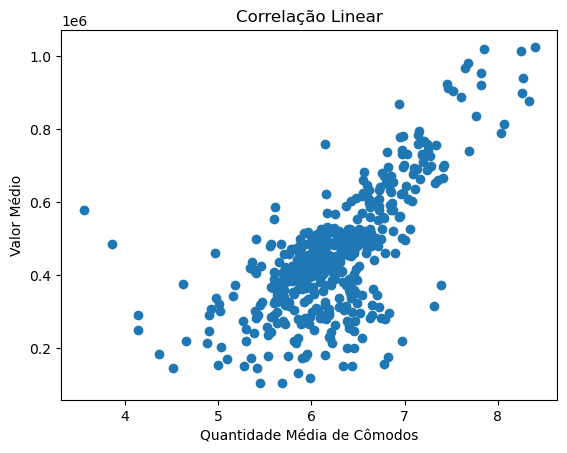

In [13]:
plt.scatter(df.RM, df.MEDV)
plt.title('Correlação Linear')
plt.xlabel('Quantidade Média de Cômodos')
plt.ylabel('Valor Médio')
plt.grid(False)

% Classe Baixa x Valor Médio

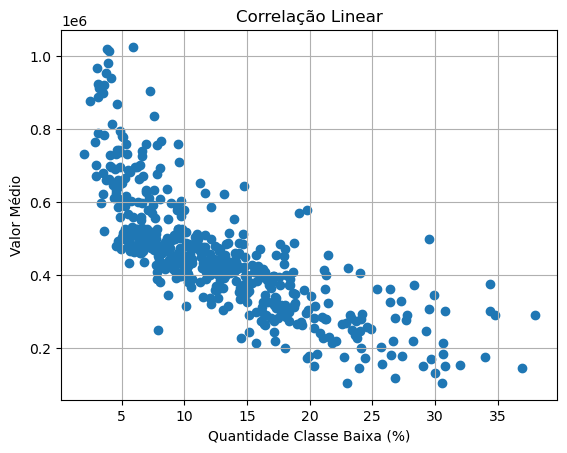

In [14]:
plt.scatter(df.LSTAT, df.MEDV)
plt.title('Correlação Linear')
plt.xlabel('Quantidade Classe Baixa (%)')
plt.ylabel('Valor Médio')
plt.grid(True)


Estudantes/Professores x Valor Médio

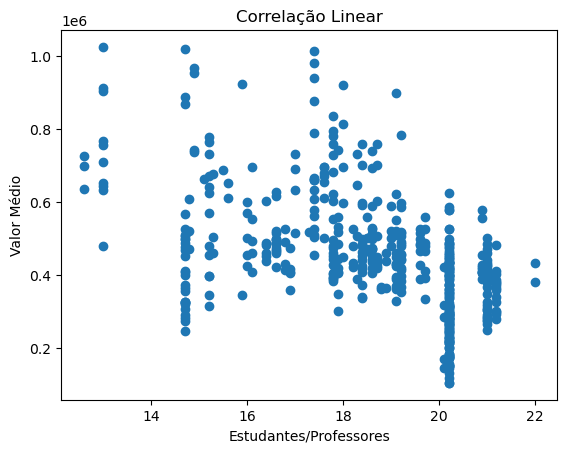

In [15]:
plt.scatter(df.PTRATIO, df.MEDV)
plt.title('Correlação Linear')
plt.xlabel('Estudantes/Professores')
plt.ylabel('Valor Médio')
plt.grid(False)

Todas Correlaçõe Pareadas

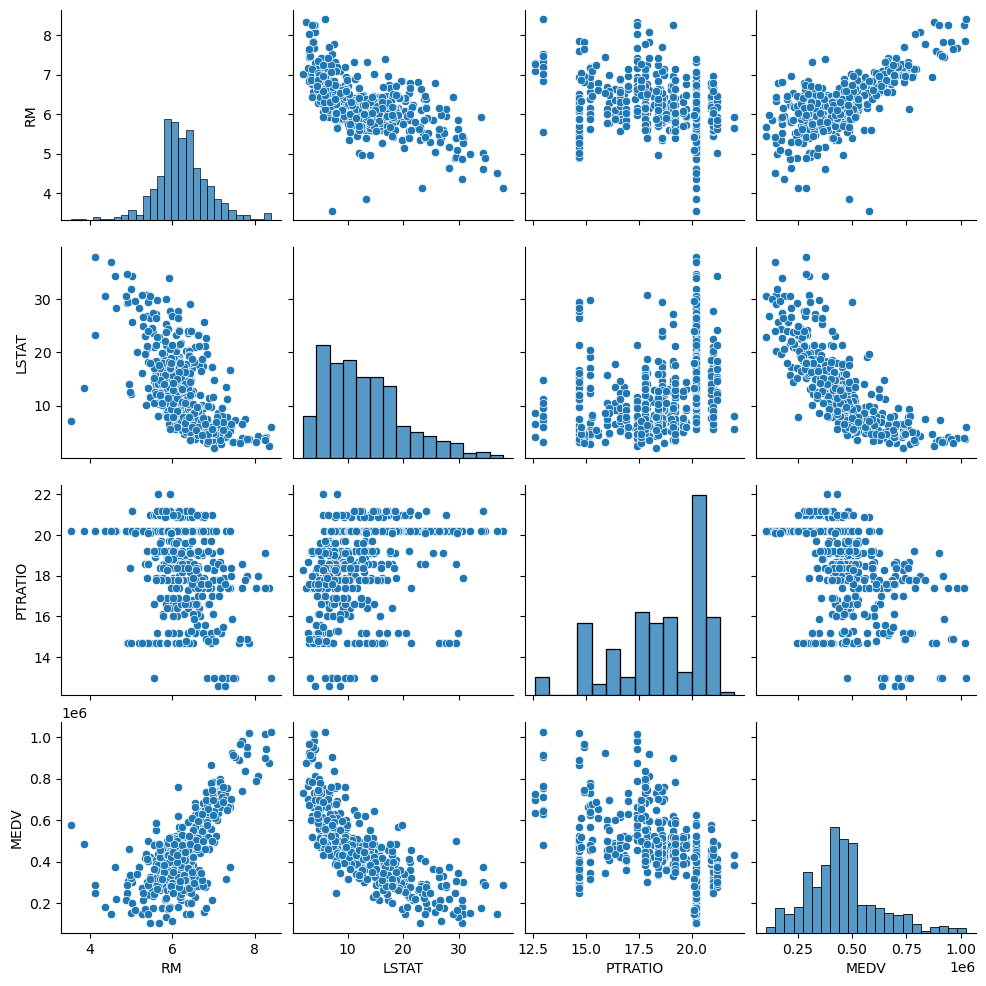

In [16]:
sns.pairplot(df);

## Análise da Normalidade

Pearson (distribuição normal)

Spearman (distribuição não normal)

Kendall (distribuição não normal com quantidade pequena de amostras)

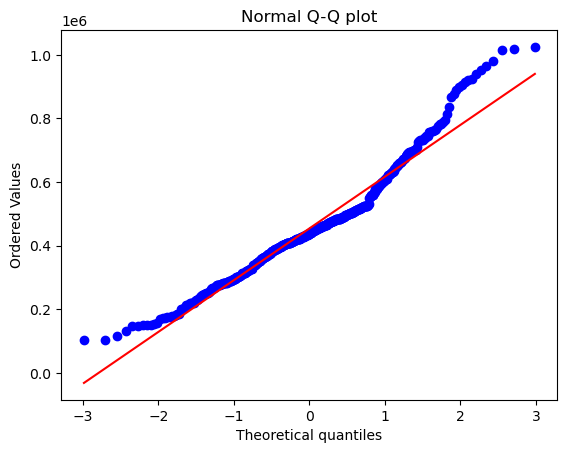

In [17]:
# Gráficos QQ-Plot
# MEDV (Valor médio das casas)

stats.probplot(df['MEDV'], dist="norm", plot=plt)
plt.title("Normal Q-Q plot")
plt.show()

In [18]:
# Histograma da variável alvo (MEDV)

hist =  px.histogram (df,  x = "MEDV", nbins=60) 
hist.update_layout(width=800,height=500,title_text='Média dos valores') 
hist.show()

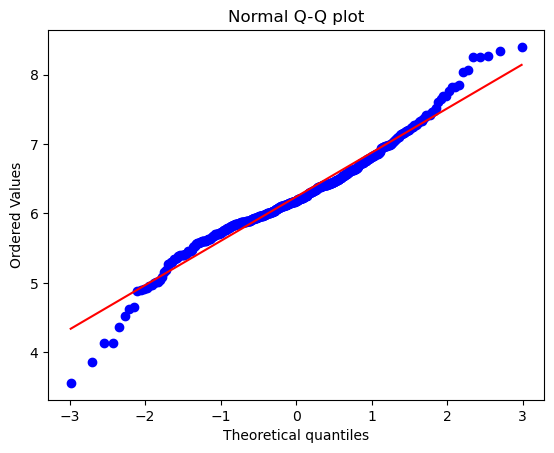

In [19]:
# Gráficos QQ-Plot
# RM (Número médio de cômodos entre os imóveis no bairro)


stats.probplot(df['RM'], dist="norm", plot=plt)
plt.title("Normal Q-Q plot")
plt.show()

In [20]:
# Histograma da variável RM (Número médio de cômodos entre os imóveis no bairro)

hist =  px.histogram (df,  x = "RM", nbins=40) 
hist.update_layout(width=800,height=500,title_text='Quantidade de cômodos') 
hist.show()

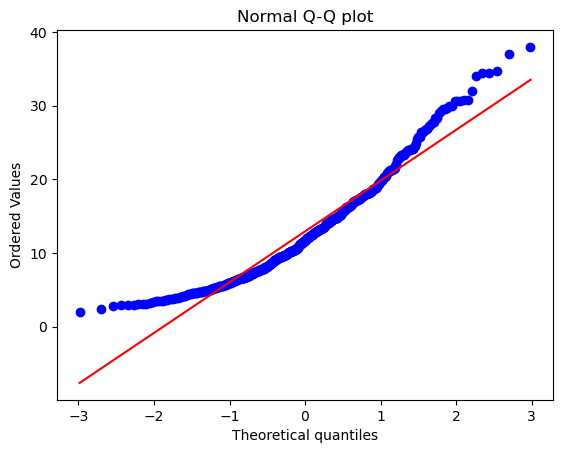

In [21]:
# Gráficos QQ-Plot
# LSTAT (Porcentagem de proprietários no bairro considerados de "classe baixa")

stats.probplot(df['LSTAT'], dist="norm", plot=plt)
plt.title("Normal Q-Q plot")
plt.show()

In [22]:
#  Histograma da variável LSTAT (Porcentagem de proprietários no bairro considerados de "classe baixa")

hist =  px.histogram (df,  x = "LSTAT", nbins=60) 
hist.update_layout(width=800,height=500,title_text='Quantidade de Classe Baixa (%)') 
hist.show()

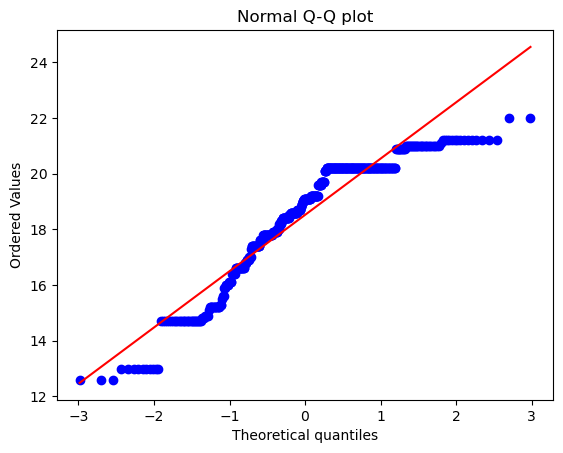

In [23]:
# Gráficos QQ-Plot
# PTRATIO (Razão entre estudantes e professores nas escolas de ensino fundamental e médio no bairro)

stats.probplot(df['PTRATIO'], dist="norm", plot=plt)
plt.title("Normal Q-Q plot")
plt.show()

In [24]:
# Histograma da variável PTRATIO (Razão entre estudantes e professores nas escolas de ensino fundamental e médio no bairro)

hist =  px.histogram (df,  x = "PTRATIO", nbins=60) 
hist.update_layout(width=800,height=500,title_text='Relação Estudantes/Professores') 
hist.show()

#### Teste Shapiro-Wilk

Ho = distribuição normal : p > 0.05

Ha = distribuição != normal : p <= 0.05

In [25]:
estatistica, p = stats.shapiro(df.MEDV)
print('Estatística do teste: {}'.format(estatistica))
print('p-valor: {}'.format(p))

Estatística do teste: 0.9596616055953767
p-valor: 2.5759801704018553e-10


In [26]:
estatistica, p = stats.shapiro(df.MEDV)
print('Estatística do teste: {}'.format(estatistica))
print('p-valor: {}'.format(p))

Estatística do teste: 0.9596616055953767
p-valor: 2.5759801704018553e-10


In [27]:
estatistica, p = stats.shapiro(df.RM)
print('Estatística do teste: {}'.format(estatistica))
print('p-valor: {}'.format(p))

Estatística do teste: 0.9708170375303297
p-valor: 2.7090145811327798e-08


In [28]:
estatistica, p = stats.shapiro(df.LSTAT)
print('Estatística do teste: {}'.format(estatistica))
print('p-valor: {}'.format(p))

Estatística do teste: 0.9371757140975832
p-valor: 1.689879707182205e-13


In [29]:
estatistica, p = stats.shapiro(df.PTRATIO)
print('Estatística do teste: {}'.format(estatistica))
print('p-valor: {}'.format(p))

Estatística do teste: 0.90647424903615
p-valor: 9.064596547331122e-17


In [30]:
# Conclusão: Nenhuma característica tem distribuição normal

#### Teste Lilliefors (Kolmogorov_Sminorv)

Ho = distribuição normal : p > 0.05

Ha = distribuição != normal : p <= 0.05

In [31]:
estatistica, p = statsmodels.stats.diagnostic.lilliefors(df.MEDV, dist = 'norm')
print('Estatística de teste: {}'.format(estatistica))
print('p-valor: {}'.format(p))

Estatística de teste: 0.11370576407672117
p-valor: 0.0009999999999998899


In [32]:
estatistica, p = statsmodels.stats.diagnostic.lilliefors(df.RM, dist = 'norm')
print('Estatística de teste: {}'.format(estatistica))
print('p-valor: {}'.format(p))

Estatística de teste: 0.06394344399233598
p-valor: 0.0009999999999998899


**Resumo das diferenças**

| Característica | Shapiro-Wilk | Kolmogorov-Smirnov |
|----------------|--------------|-------------------|
| Tipo de teste | Normalidade | Comparação com qualquer distribuição teórica |
| Base | Correlação entre dados e valores normais esperados | Máxima diferença entre CDF amostral e teórica |
| Potência | Alta para amostras pequenas | Média a baixa para pequenas amostras |
| Uso | Testar normalidade | Testar normalidade ou qualquer outra distribuição |


Pearson (distribuição normal)

Spearman (distribuição não normal)

Kendall (distribuição não normal com quantidade pequena de amostras)

In [33]:
# Pearson
coef,p = stats.pearsonr(df.MEDV, df.RM)
print('Coeficiente de correlação: {}'.format(coef))
print('p-valor: {}'.format(p))

Coeficiente de correlação: 0.6972092210185155
p-valor: 2.0533141149513303e-72


In [34]:
# Spearman
coef,p = stats.spearmanr(df.MEDV, df.PTRATIO)
print('Coeficiente de correlação: {}'.format(coef))
print('p-valor: {}'.format(p))

Coeficiente de correlação: -0.5592761164167336
p-valor: 1.3794858687631326e-41


In [35]:
# Kendall
coef,p = stats.kendalltau(df.MEDV,df.RM)
print('Coeficiente de correlação: {}'.format(coef))
print('p-valor: {}'.format(p))

Coeficiente de correlação: 0.4724931551110662
p-valor: 9.983146011545424e-55


Utilizaremos a correlação de **Spearman** em função das variáveis não seguirem uma distribuição normal

### Correlação para distribuições **não normais**

In [36]:
correlacoes = df.corr(method='spearman')
correlacoes

,RM,LSTAT,PTRATIO,MEDV
RM,1.000000,-0.624700,-0.282053,0.624057
LSTAT,-0.624700,1.000000,0.461739,-0.845527
PTRATIO,-0.282053,0.461739,1.000000,-0.559276
MEDV,0.624057,-0.845527,-0.559276,1.000000


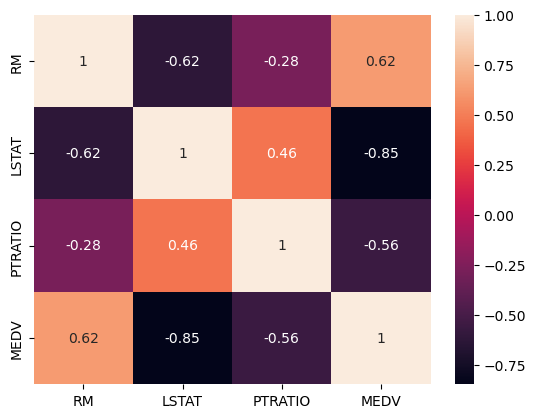

In [37]:
plt.figure()
sns.heatmap(correlacoes, annot=True);

## Regressão Linear Simples

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html 

### 1) Regressão com Valor médio (MEDV) em função do número de cômodos (RM)

In [38]:
# Variáveis previsoras

x1 = df.iloc[:,0:1].values
x1

array([[6.575],
       [6.421],
       [7.185],
       [6.998],
       [7.147],
       [6.43 ],
       [6.012],
       [6.172],
       [5.631],
       [6.004],
       [6.377],
       [6.009],
       [5.889],
       [5.949],
       [6.096],
       [5.834],
       [5.935],
       [5.99 ],
       [5.456],
       [5.727],
       [5.57 ],
       [5.965],
       [6.142],
       [5.813],
       [5.924],
       [5.599],
       [5.813],
       [6.047],
       [6.495],
       [6.674],
       [5.713],
       [6.072],
       [5.95 ],
       [5.701],
       [6.096],
       [5.933],
       [5.841],
       [5.85 ],
       [5.966],
       [6.595],
       [7.024],
       [6.77 ],
       [6.169],
       [6.211],
       [6.069],
       [5.682],
       [5.786],
       [6.03 ],
       [5.399],
       [5.602],
       [5.963],
       [6.115],
       [6.511],
       [5.998],
       [5.888],
       [7.249],
       [6.383],
       [6.816],
       [6.145],
       [5.927],
       [5.741],
       [5.966],
       [

In [39]:
# Variável alvo

y = df.iloc[:, 3].values
y

array([ 504000.,  453600.,  728700.,  701400.,  760200.,  602700.,
        480900.,  569100.,  346500.,  396900.,  315000.,  396900.,
        455700.,  428400.,  382200.,  417900.,  485100.,  367500.,
        424200.,  382200.,  285600.,  411600.,  319200.,  304500.,
        327600.,  291900.,  348600.,  310800.,  386400.,  441000.,
        266700.,  304500.,  277200.,  275100.,  283500.,  396900.,
        420000.,  441000.,  518700.,  646800.,  732900.,  558600.,
        531300.,  518700.,  445200.,  405300.,  420000.,  348600.,
        302400.,  407400.,  413700.,  430500.,  525000.,  491400.,
        396900.,  743400.,  518700.,  663600.,  489300.,  411600.,
        392700.,  336000.,  466200.,  525000.,  693000.,  493500.,
        407400.,  462000.,  365400.,  438900.,  508200.,  455700.,
        478800.,  491400.,  506100.,  449400.,  420000.,  436800.,
        445200.,  426300.,  588000.,  501900.,  520800.,  480900.,
        501900.,  558600.,  472500.,  466200.,  495600.,  6027

In [40]:
x_treino, x_teste, y_treino, y_teste = train_test_split(x1, y, test_size=0.3, random_state=10)

In [41]:
x_treino.shape, y_treino.shape

((342, 1), (342,))

In [42]:
x_teste.shape, y_teste.shape

((147, 1), (147,))

In [43]:
reg_linear1 = LinearRegression()
reg_linear1.fit(x_treino, y_treino)

LinearRegression()

In [44]:
# Intercepto (coeficiente linear)
reg_linear1.intercept_

np.float64(-626510.2699464147)

In [45]:
# Coeficiente Angular
reg_linear1.coef_

array([173771.45170999])

Equação: Valor = -626510,27 + 173771,45.número_cômodos

#### Coeficiente de Determinação (R²) com `.score()`

No scikit-learn, o método `.score(X, y)` para modelos de **regressão** retorna o 
**coeficiente de determinação (R²)**.

#### 🔹 O que é o R²?
O R² mede o quanto da **variância da variável dependente (y)** é explicada pelo modelo em 
função das variáveis independentes (X).  

- **R² = 1.0** → modelo perfeito, explica 100% da variância.  
- **R² = 0.0** → o modelo não explica nada além da média de `y`.  
- **R² < 0** → o modelo é pior que simplesmente prever a média de `y`.


#### 🔹 Exemplo de interpretação
Se `reg_linear1.score(x_treino, y_treino) = 0.85`, isso significa que:

👉 **85% da variação nos valores de treino é explicada pelas variáveis preditoras do modelo.**  
O restante (15%) corresponde a fatores que o modelo não conseguiu capturar.


#### 🔹 Importância de avaliar treino e teste
- Avaliar apenas no **treino** pode enganar:  
  - R² alto no treino e baixo no teste → **overfitting** (modelo decorou os dados).  
  - R² parecido no treino e teste → modelo generaliza bem.  

Por isso, é comum comparar:
```python
r2_treino = reg_linear1.score(x_treino, y_treino)
r2_teste  = reg_linear1.score(x_teste, y_teste)


In [46]:
# Coeficiente de Determinação dados de treino R^2
reg_linear1.score(x_treino, y_treino)

0.46368351515551953

In [47]:
# Coeficiente de Determinação dados de teste R^2
reg_linear1.score(x_teste, y_teste)

0.5426573915930197

In [48]:
# Valores baixos, tanto em treino quanto em teste, usar outro modelo é o mais indicado

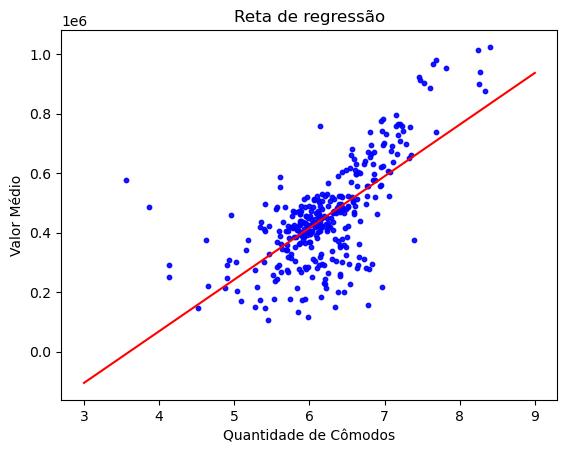

In [49]:
# Quantidade de Cômodos x Valor Médio (Treino)

plt.scatter(y=y_treino, x=x_treino, color='blue', s=10, alpha=0.9)

X_plot = np.linspace(3, 9)    # número de cômodos
plt.plot(X_plot, X_plot*reg_linear1.coef_ + reg_linear1.intercept_, color='r')

plt.title('Reta de regressão')
plt.ylabel('Valor Médio')
plt.xlabel('Quantidade de Cômodos')

plt.show()

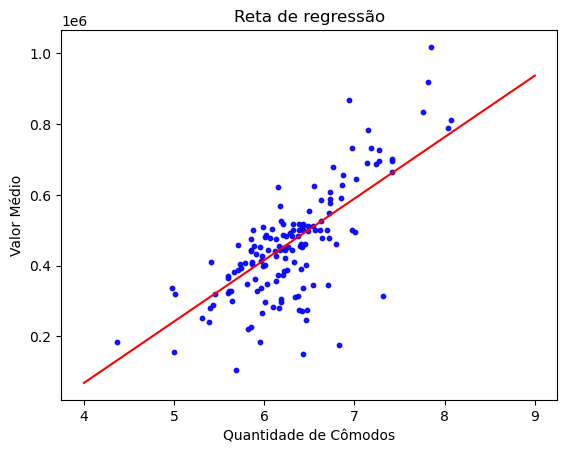

In [50]:
# Quantidade de Cômodos x Valor Médio (Teste)

plt.scatter(y=y_teste, x=x_teste, color='blue', s=10, alpha=0.9)

X_plot = np.linspace(4, 9)    # número de cômodos
plt.plot(X_plot, X_plot*reg_linear1.coef_ + reg_linear1.intercept_, color='r')

plt.title('Reta de regressão')
plt.ylabel('Valor Médio')
plt.xlabel('Quantidade de Cômodos')

plt.show()

In [51]:
previsoes_treino = reg_linear1.predict(x_treino)
previsoes_treino

array([551833.94409904, 468423.64727824, 647755.78544295, 658182.07254555,
       586414.46298932, 464600.67534062, 395265.86610833, 229487.901177  ,
       441141.52935977, 424980.78435074, 523161.65456689, 432105.41387085,
       555135.60168153,  44768.84800928, 504915.65213734, 424285.6985439 ,
       565735.66023583, 607962.12300136, 455912.10275512, 442531.70097345,
       505784.50939589, 450003.87339698, 410210.21095539, 390226.49400874,
       472767.93357099, 809884.54988837, 401174.09546647, 639762.29866429,
       465817.07550259, 491882.79325909, 437318.55742215, 416813.52612037,
       413164.32563446, 560870.05958796, 396134.72336688, 459561.30324103,
       335488.4867201 , 521423.94004979, 441315.30081148, 630899.95462708,
       452262.90226921, 557915.94490889, 437144.78597044, 391616.66562242,
       525420.68343912, 459735.07469274, 397872.43788398, 492925.42196935,
       387619.92223309, 533240.39876607, 487538.50696634, 608483.43735649,
       832822.38151409, 4

In [52]:
previsoes_teste = reg_linear1.predict(x_teste)
previsoes_teste

array([419593.86934773, 438187.4146807 , 447744.84452475, 480935.19180136,
       491013.93600054, 494836.90793816, 563650.40281531, 438187.4146807 ,
       500745.1372963 , 482151.59196333, 452436.67372092, 452784.21662434,
       585719.37718248, 394744.5517532 , 321239.22767988, 442705.47242516,
       458171.13162735, 446702.21581449, 442357.92952174, 488581.1356766 ,
       592322.69234746, 244432.24602406, 412816.78273104, 540365.02828618,
       421331.58386483, 554092.97297127, 470856.44760218, 369373.91980354,
       732382.48242572, 411947.92547249, 484758.16373898, 514646.8534331 ,
       565561.88878412, 438534.95758412, 661483.73012804, 452957.98807605,
       579984.91927605, 402911.80998357, 351475.46027742, 537063.37070369,
       491535.25035567, 490145.07874199, 637503.26979206, 512735.36746429,
       722825.05258167, 631768.81188563, 489971.30729028, 353039.40334281,
       471551.53340902, 466512.16130943, 446007.13000765, 384492.03610231,
       390747.80836387, 3

In [53]:
# Fazendo previsões para valores distintos
valor_casa = reg_linear1.predict([[4]])   # 4 cômodos
valor_casa

array([68575.53689355])

### Métricas de Desempenho

In [54]:
# Erro absoluto
abs(y_teste - previsoes_teste).mean()

np.float64(76063.99733079868)

In [55]:
# Erro médio absoluto
mean_absolute_error(y_teste, previsoes_teste)

76063.99733079868

In [56]:
# Erro quadrático médio
mean_squared_error(y_teste, previsoes_teste)

11294624525.740467

In [57]:
# Raiz do erro quadrático médio
np.sqrt(mean_squared_error(y_teste, previsoes_teste))

np.float64(106276.17101561604)

## 2) Regressão Linear com Valor médio (MEDV) em função da classe social (LSTAT)

In [58]:
x2 = df.iloc[:,1:2].values
x2

array([[ 4.98],
       [ 9.14],
       [ 4.03],
       [ 2.94],
       [ 5.33],
       [ 5.21],
       [12.43],
       [19.15],
       [29.93],
       [17.1 ],
       [20.45],
       [13.27],
       [15.71],
       [ 8.26],
       [10.26],
       [ 8.47],
       [ 6.58],
       [14.67],
       [11.69],
       [11.28],
       [21.02],
       [13.83],
       [18.72],
       [19.88],
       [16.3 ],
       [16.51],
       [14.81],
       [17.28],
       [12.8 ],
       [11.98],
       [22.6 ],
       [13.04],
       [27.71],
       [18.35],
       [20.34],
       [ 9.68],
       [11.41],
       [ 8.77],
       [10.13],
       [ 4.32],
       [ 1.98],
       [ 4.84],
       [ 5.81],
       [ 7.44],
       [ 9.55],
       [10.21],
       [14.15],
       [18.8 ],
       [30.81],
       [16.2 ],
       [13.45],
       [ 9.43],
       [ 5.28],
       [ 8.43],
       [14.8 ],
       [ 4.81],
       [ 5.77],
       [ 3.95],
       [ 6.86],
       [ 9.22],
       [13.15],
       [14.44],
       [

In [59]:
y = df.iloc[:, 3].values
y

array([ 504000.,  453600.,  728700.,  701400.,  760200.,  602700.,
        480900.,  569100.,  346500.,  396900.,  315000.,  396900.,
        455700.,  428400.,  382200.,  417900.,  485100.,  367500.,
        424200.,  382200.,  285600.,  411600.,  319200.,  304500.,
        327600.,  291900.,  348600.,  310800.,  386400.,  441000.,
        266700.,  304500.,  277200.,  275100.,  283500.,  396900.,
        420000.,  441000.,  518700.,  646800.,  732900.,  558600.,
        531300.,  518700.,  445200.,  405300.,  420000.,  348600.,
        302400.,  407400.,  413700.,  430500.,  525000.,  491400.,
        396900.,  743400.,  518700.,  663600.,  489300.,  411600.,
        392700.,  336000.,  466200.,  525000.,  693000.,  493500.,
        407400.,  462000.,  365400.,  438900.,  508200.,  455700.,
        478800.,  491400.,  506100.,  449400.,  420000.,  436800.,
        445200.,  426300.,  588000.,  501900.,  520800.,  480900.,
        501900.,  558600.,  472500.,  466200.,  495600.,  6027

In [60]:
x_treino, x_teste, y_treino, y_teste = train_test_split(x2, y, test_size = 0.3, random_state = 10)

In [61]:
x_treino.shape, y_treino.shape

((342, 1), (342,))

In [62]:
x_teste.shape, y_teste.shape

((147, 1), (147,))

In [63]:
reg_linear2 = LinearRegression()
reg_linear2.fit(x_treino, y_treino)

LinearRegression()

In [64]:
# Intercepto (coeficiente linear)
reg_linear2.intercept_

np.float64(681977.7451055485)

In [65]:
# Coeficiente Angular
reg_linear2.coef_

array([-17263.75010515])

### Equação: Valor = 681977,75 - 17263,75.LSTAT

In [66]:
# Coeficiente de Determinação dados de treino
reg_linear2.score(x_treino, y_treino)

0.5688289563355992

In [67]:
# Coeficiente de Determinação dados de treino
reg_linear2.score(x_teste, y_teste)

0.6006038196307661

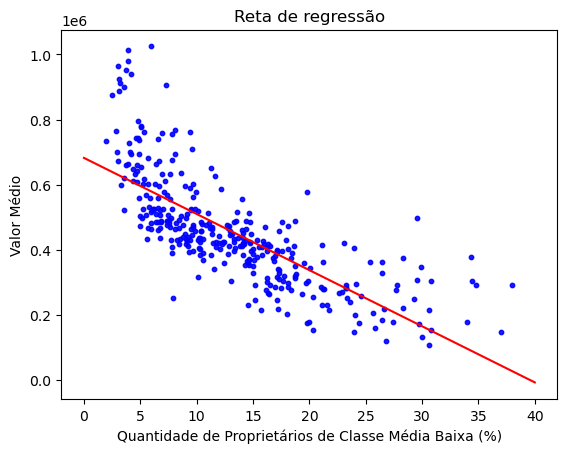

In [68]:
# Quantidade de Proprietários de Classe Média Baixa (%) x Valor Médio (Treino)

plt.scatter(y=y_treino, x=x_treino, color='blue', s=10, alpha=0.9)

X_plot = np.linspace(0, 40)
plt.plot(X_plot, X_plot*reg_linear2.coef_ + reg_linear2.intercept_, color='r')

plt.title('Reta de regressão')
plt.ylabel('Valor Médio')
plt.xlabel('Quantidade de Proprietários de Classe Média Baixa (%)')

plt.show()

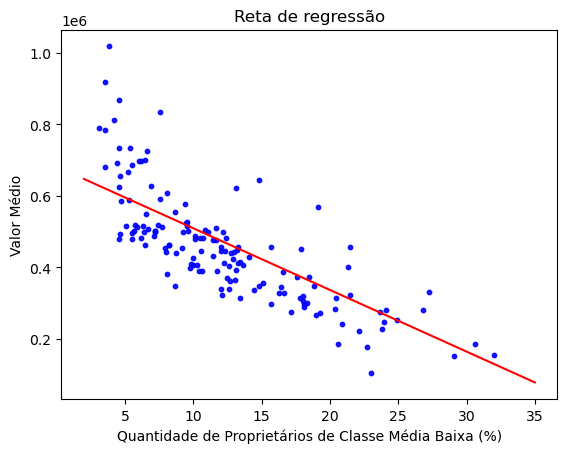

In [69]:
# Quantidade de Proprietários de Classe Média Baixa (%) x Valor Médio (Teste)

plt.scatter(y=y_teste, x=x_teste, color='blue', s=10, alpha=0.9)

X_plot = np.linspace(2, 35)
plt.plot(X_plot, X_plot*reg_linear2.coef_ + reg_linear2.intercept_, color='r')

plt.title('Reta de regressão')
plt.ylabel('Valor Médio')
plt.xlabel('Quantidade de Proprietários de Classe Média Baixa (%)')

plt.show()

In [70]:
previsoes_treino = reg_linear2.predict(x_treino)
previsoes_treino

array([549564.78179906, 401787.080899  , 547493.13178645, 392982.56834537,
       594968.4445756 , 475330.65634693, 474294.83134062, 172179.20450053,
       525050.25664975, 358109.79313297, 527812.45666658, 386940.25580857,
       595141.08207665, 451851.95620393, 590825.14455037, 383660.14328859,
       624489.45725541, 543004.55675911, 413526.4309705 , 422676.21852623,
       572180.29443681, 457548.99373862, 507095.9565404 , 397643.78087376,
       492594.40645207, 610505.81967024, 365533.20567819, 611541.64467654,
       527639.81916553, 401959.71840005, 578740.51947676, 435624.03110509,
       370021.78070552, 342054.50553518, 530229.3816813 , 587027.11952723,
       274553.24262406, 554743.90683061, 563548.41938423, 562339.95687687,
       420086.65601045, 613785.93219021, 536271.6942181 , 515555.19409192,
       280250.28015875, 437005.1311135 , 499672.54399519, 541105.54424754,
       359836.16814349, 475158.01884588, 422676.21852623, 533336.85670022,
       579948.98198412, 5

In [71]:
previsoes_teste = reg_linear2.predict(x_teste)
previsoes_teste

array([507441.2315425 , 438731.50612401, 518490.0316098 , 500708.36900149,
       594277.8945714 , 539897.08174018, 551981.70681378, 483789.89389845,
       580121.61948518, 272999.50511459, 558714.56935479, 553535.44432325,
       584610.19451251, 472395.81882905, 370194.41820658, 454959.43122285,
       496565.06897626, 474122.19383957, 363288.91816452, 348614.73057514,
       426646.88105041, 472741.09383115, 480855.05638057, 506578.04403724,
       357419.24312877, 570108.64442419, 573388.75694417, 447018.10617448,
       620346.15723017, 353793.85560668, 452887.78121023, 521770.14412977,
       562512.59437792, 420949.84351571, 591343.05705352, 378135.74325494,
       602737.13212292, 400578.61839164, 394536.30585483, 558024.01935059,
       180465.804551  , 557678.74434848, 567691.71940947, 603255.04462607,
       551463.79431063, 587199.75702829, 474294.83134062, 365360.56817713,
       490350.11893841, 601356.03211451, 351376.93059196, 300276.23028073,
       271273.13010408, 4

In [72]:
# Fazendo previsões para valores distintos
valor_casa = reg_linear2.predict([[25]])
valor_casa

array([250383.99247685])

### Métricas de Desempenho

In [73]:
# Erro absoluto
abs(y_teste - previsoes_teste).mean()

np.float64(76340.55192245146)

In [74]:
# Erro médio Absoluto
mean_absolute_error(y_teste, previsoes_teste)

76340.55192245146

In [75]:
# Erro quadrático médio
mean_squared_error(y_teste, previsoes_teste)

9863567949.634672

In [76]:
# Raiz do erro quadrático médio (RMSE)
np.sqrt(mean_squared_error(y_teste, previsoes_teste))

np.float64(99315.49702657018)

### Validação Cruzada

In [77]:
# Separando os dados em folds
kfold = KFold(n_splits = 15, shuffle=True, random_state = 5)

In [78]:
# Criando o modelo
modelo = LinearRegression()

resultado = cross_val_score(modelo, x2, y, cv = kfold)   # validação cruzada do modelo 2
resultado # coefficiente de determinação para cada fold

array([0.73997836, 0.52496442, 0.2753212 , 0.77336843, 0.7096672 ,
       0.34726472, 0.66194425, 0.68820343, 0.411042  , 0.5519506 ,
       0.5776707 , 0.37648029, 0.60443851, 0.64797086, 0.5056103 ])

In [79]:
# Média do coef de determinação da validação cruzada
print("Coef. determinação Médio: %.2f%%" % (resultado.mean() * 100.0))

Coef. determinação Médio: 55.97%


In [80]:
# Coeficientes de determinação R^2

# Treino: 56%

# Teste: 60%

# Cruzada Média: 56%

## Regressão com Statsmodels

In [81]:
x2 = df.iloc[:,1:2].values
x2

array([[ 4.98],
       [ 9.14],
       [ 4.03],
       [ 2.94],
       [ 5.33],
       [ 5.21],
       [12.43],
       [19.15],
       [29.93],
       [17.1 ],
       [20.45],
       [13.27],
       [15.71],
       [ 8.26],
       [10.26],
       [ 8.47],
       [ 6.58],
       [14.67],
       [11.69],
       [11.28],
       [21.02],
       [13.83],
       [18.72],
       [19.88],
       [16.3 ],
       [16.51],
       [14.81],
       [17.28],
       [12.8 ],
       [11.98],
       [22.6 ],
       [13.04],
       [27.71],
       [18.35],
       [20.34],
       [ 9.68],
       [11.41],
       [ 8.77],
       [10.13],
       [ 4.32],
       [ 1.98],
       [ 4.84],
       [ 5.81],
       [ 7.44],
       [ 9.55],
       [10.21],
       [14.15],
       [18.8 ],
       [30.81],
       [16.2 ],
       [13.45],
       [ 9.43],
       [ 5.28],
       [ 8.43],
       [14.8 ],
       [ 4.81],
       [ 5.77],
       [ 3.95],
       [ 6.86],
       [ 9.22],
       [13.15],
       [14.44],
       [

In [82]:
y = df.iloc[:, 3].values
y

array([ 504000.,  453600.,  728700.,  701400.,  760200.,  602700.,
        480900.,  569100.,  346500.,  396900.,  315000.,  396900.,
        455700.,  428400.,  382200.,  417900.,  485100.,  367500.,
        424200.,  382200.,  285600.,  411600.,  319200.,  304500.,
        327600.,  291900.,  348600.,  310800.,  386400.,  441000.,
        266700.,  304500.,  277200.,  275100.,  283500.,  396900.,
        420000.,  441000.,  518700.,  646800.,  732900.,  558600.,
        531300.,  518700.,  445200.,  405300.,  420000.,  348600.,
        302400.,  407400.,  413700.,  430500.,  525000.,  491400.,
        396900.,  743400.,  518700.,  663600.,  489300.,  411600.,
        392700.,  336000.,  466200.,  525000.,  693000.,  493500.,
        407400.,  462000.,  365400.,  438900.,  508200.,  455700.,
        478800.,  491400.,  506100.,  449400.,  420000.,  436800.,
        445200.,  426300.,  588000.,  501900.,  520800.,  480900.,
        501900.,  558600.,  472500.,  466200.,  495600.,  6027

In [83]:
# Modelo de regressão usando statsmodels

regressao = smf.ols('y ~ x2', data = df).fit()

In [84]:
# Resíduos do modelo de regressão

residuos = regressao.resid
residuos

0      -91698.432398
1      -68220.791356
2      116130.471691
3       69473.109014
4      170717.234516
           ...      
484    -42008.495743
485    -90286.334256
486    -82077.460502
487   -107059.859907
488   -294297.192249
Length: 489, dtype: float64

In [85]:
# Para um modelo bem ajustado, os resíduos devem se comportar como um ruído branco, isto é seguirem distribuição normal com média zero e variância constante.

#### Teste de Normalidade dos resíduos

Ho = distribuição normal : p > 0.05

Ha = distribuição != normal : p <= 0.05

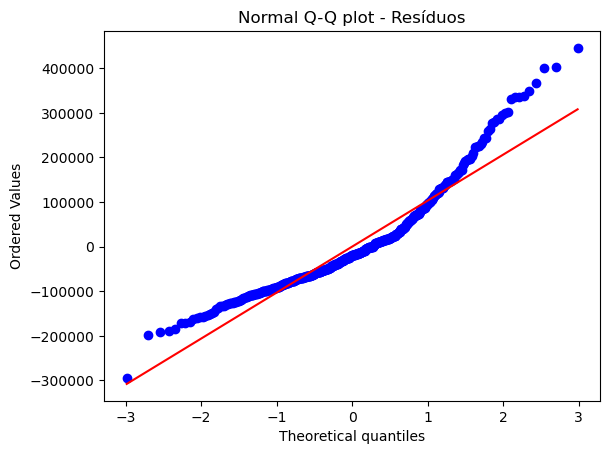

In [86]:
# Gráficos QQ-Plot dos resíduos

stats.probplot(residuos, dist="norm", plot=plt)
plt.title("Normal Q-Q plot - Resíduos")
plt.show()

In [87]:
estatistica, p = stats.shapiro(residuos)
print('Estatística de teste: {}'.format(estatistica))
print('p-valor: {}'.format(p))

Estatística de teste: 0.9171057147431392
p-valor: 9.78292336065136e-16


In [88]:
# Resíduos não normal

#### Análise da Homocedasticidade dos resíduos
(resíduos com variação constante)

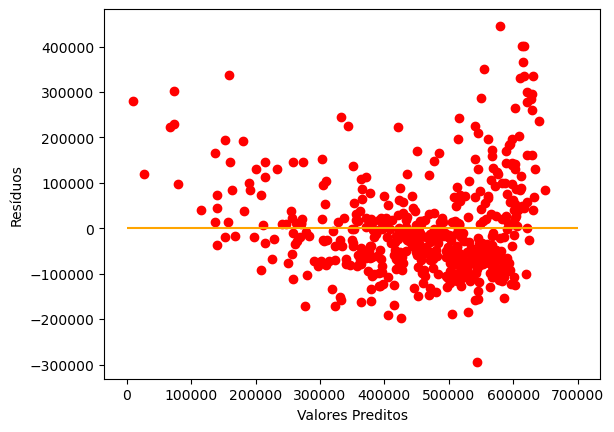

In [89]:
plt.scatter(y=residuos, x=regressao.predict(), color='red')

plt.hlines(y=0, xmin=0, xmax=700000, color='orange')

plt.ylabel('Resíduos')
plt.xlabel('Valores Preditos')

plt.show()

### Teste Breusch-Pagan (Homocedasticidade ou heterocedasticidade)

Ho = existe homocedasticidade : p > 0.05

Ha = não existe homocedasticidade : p <= 0.05

In [90]:
estatistica, p, f, fp = sms.het_breuschpagan (regressao.resid, regressao.model.exog)

print('Estatística de teste: {}'.format(estatistica))
print('p-valor: {}'.format(p))
print('f-valor: {}'.format(f))
print('f_p-valor: {}'.format(fp))

Estatística de teste: 5.382553364026837
p-valor: 0.020339089399131132
f-valor: 5.4202004218722095
f_p-valor: 0.02031369218146316


In [91]:
# Resíduo não tem variância constante (Heterocedasticidade)

#### **Outliers nos resíduos**

(Entre -3 e 3)

In [92]:
outliers = regressao.outlier_test()

In [93]:
outliers.max()

student_resid    4.227468
unadj_p          0.999732
bonf(p)          1.000000
dtype: float64

In [94]:
outliers.min()

student_resid   -2.762057
unadj_p          0.000028
bonf(p)          0.013809
dtype: float64

### Modelo de Regressão Linear

p_valor para cada coeficiente < 0,05 (estatisticamente significativos).

Adjusted R-squared (explicação do modelo através dos dados).

p_valor da estatística F < 0.05 (valida o modelo de regressão).

In [95]:
print(regressao.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.579
Model:                            OLS   Adj. R-squared:                  0.578
Method:                 Least Squares   F-statistic:                     668.7
Date:                Mon, 20 Oct 2025   Prob (F-statistic):           1.93e-93
Time:                        12:42:45   Log-Likelihood:                -6357.8
No. Observations:                 489   AIC:                         1.272e+04
Df Residuals:                     487   BIC:                         1.273e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   6.841e+05   1.01e+04     67.551      0.0

**Estatística t:**

Ho = coeficiente igual a zero : p > 0,05 (coeficiente não validado)

Ha = coeficiente diferente de zero: p <= 0,05 (coeficiente validado)

R^2 ajustado = 0,578

In [96]:
coefs = pd.DataFrame(regressao.params)
coefs.columns = ['Coeficientes']
print(coefs)

            Coeficientes
Intercept  684138.493068
x2         -17759.048327


### Equação: Valor = 684138,49 - 17759.04.LSTAT

In [97]:
regressao.params

Intercept    684138.493068
x2           -17759.048327
dtype: float64

In [98]:
regressao.predict()

array([595698.43239814, 521820.79135628, 612569.52830915, 631926.89098598,
       589482.76548356, 591613.85128285, 463393.52235923, 344052.7175993 ,
       152610.17663024, 380458.76667041, 320965.95477372, 448475.92176424,
       405143.84384546, 537448.75388437, 501930.65722963, 533719.35373562,
       567283.95507435, 423613.25410592, 476535.21812149, 483816.42793571,
       310843.29722712, 438530.85470091, 351689.10838007, 331088.61232032,
       394666.00533231, 390936.60518356, 421126.98734009, 377262.13797148,
       456822.6744781 , 471385.09410655, 282784.00086987, 452560.50287954,
       192035.26391701, 358259.9562612 , 322919.45008973, 512230.9052595 ,
       481507.75165315, 528391.63923741, 504239.33351218, 607419.40429421,
       648975.57738026, 598184.69916398, 580958.42228643, 552011.17351281,
       514539.58154206, 502818.60964599, 432847.95923615, 350268.38451388,
       136982.21410216, 396441.91016504, 445279.29306531, 516670.66734134,
       590370.71789993, 5

C:\Users\mau_a\AppData\Local\Temp\ipykernel_18456\354171672.py:6: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



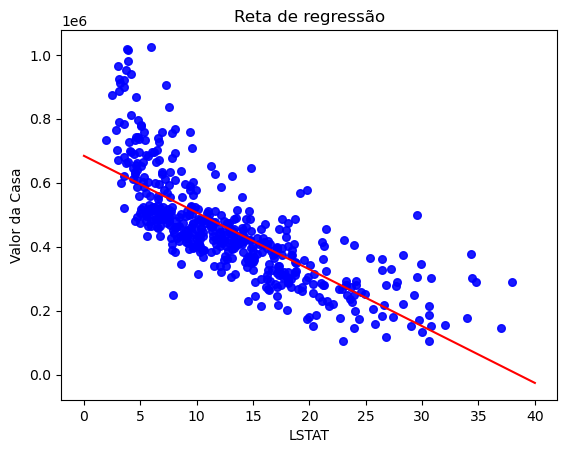

In [99]:
# Quantidade de Proprietários de Classe Média Baixa (%) x Valor da Casa (Statsmodels)

plt.scatter(y=df.MEDV, x=df.LSTAT, color='blue', s=30, alpha=0.9)

X_plot = np.linspace(0, 40)
plt.plot(X_plot, X_plot*regressao.params[1] + regressao.params[0], color='r')

plt.title('Reta de regressão')
plt.ylabel('Valor da Casa')
plt.xlabel('LSTAT')

plt.show()

## Regressão Linear Múltipla

In [100]:
independente = df.iloc[:, 0:3].values
independente

array([[ 6.575,  4.98 , 15.3  ],
       [ 6.421,  9.14 , 17.8  ],
       [ 7.185,  4.03 , 17.8  ],
       ...,
       [ 6.976,  5.64 , 21.   ],
       [ 6.794,  6.48 , 21.   ],
       [ 6.03 ,  7.88 , 21.   ]])

In [101]:
dependente = df.iloc[:, 3].values
dependente

array([ 504000.,  453600.,  728700.,  701400.,  760200.,  602700.,
        480900.,  569100.,  346500.,  396900.,  315000.,  396900.,
        455700.,  428400.,  382200.,  417900.,  485100.,  367500.,
        424200.,  382200.,  285600.,  411600.,  319200.,  304500.,
        327600.,  291900.,  348600.,  310800.,  386400.,  441000.,
        266700.,  304500.,  277200.,  275100.,  283500.,  396900.,
        420000.,  441000.,  518700.,  646800.,  732900.,  558600.,
        531300.,  518700.,  445200.,  405300.,  420000.,  348600.,
        302400.,  407400.,  413700.,  430500.,  525000.,  491400.,
        396900.,  743400.,  518700.,  663600.,  489300.,  411600.,
        392700.,  336000.,  466200.,  525000.,  693000.,  493500.,
        407400.,  462000.,  365400.,  438900.,  508200.,  455700.,
        478800.,  491400.,  506100.,  449400.,  420000.,  436800.,
        445200.,  426300.,  588000.,  501900.,  520800.,  480900.,
        501900.,  558600.,  472500.,  466200.,  495600.,  6027

In [102]:
x_treino, x_teste, y_treino, y_teste = train_test_split(independente, dependente, test_size = 0.3, random_state = 0)

In [103]:
multipla = LinearRegression()
multipla.fit(x_treino, y_treino)

LinearRegression()

In [104]:
multipla.intercept_

np.float64(434789.45509552275)

In [105]:
multipla.coef_

array([ 85325.36412937, -10775.41479323, -20133.58779106])

In [106]:
print("Equação: Valor = {:.2f} + ({:.2f})*RM + ({:.2f})*LSTAT + ({:.2f})*PTRATIO".format(multipla.intercept_, multipla.coef_[0], multipla.coef_[1], multipla.coef_[2]))

Equação: Valor = 434789.46 + (85325.36)*RM + (-10775.41)*LSTAT + (-20133.59)*PTRATIO


In [107]:
# Coeficiente de Determinação R^2 (Treino)
multipla.score(x_treino, y_treino)

0.7343049403294957

In [108]:
# Coeficiente de Determinação R^2 (Teste)
multipla.score(x_teste, y_teste)

0.6817814124380092

In [109]:
previsoes = multipla.predict(x_teste)
previsoes

array([418504.52251533, 682498.59311161, 310842.03220354, 399602.67212048,
       529013.04970446, 364349.16756502, 241564.07559959, 413075.10184459,
       476051.89023052, 371925.92192458, 324382.18849665, 357068.87403347,
       472650.96518839,  52625.76046357, 486476.7874084 , 312653.08514703,
       465067.60969605, 614663.51972717, 383059.21254559, 653229.85415898,
       677008.34036381, 653364.33988067,  15201.46316315, 452877.56192735,
       360692.75896586, 754677.40725013, 714803.22773315, 754640.19558449,
       430756.93101727, 422579.57707332, 378309.3992427 , 461958.22362764,
       472103.18520444, 681780.56381622, 457070.41410848, 769207.31373834,
       520822.33816699, 261675.315203  , 503180.52774604, 590132.54786611,
       324624.03541901, 452521.53520288, 400704.94316867, 498314.39406844,
       280336.01343561, 365481.99718596, 525798.46427921, 361547.63013434,
       716795.14226269, 407424.79029782, 679886.98036124, 445827.68346551,
       614892.98134094, 3

In [110]:
# Fazendo previsões para valores distintos
valor_casa = multipla.predict([[6,20,12]])
valor_casa

array([489630.29051446])

### Métricas de Desempenho

In [111]:
# Erro absoluto
abs(y_teste - previsoes).mean()

np.float64(71651.46435650408)

In [112]:
# Erro médio Absoluto
mean_absolute_error(y_teste, previsoes)

71651.46435650408

In [113]:
# Erro quadrático médio
mean_squared_error(y_teste, previsoes)

9232768512.15146

In [114]:
# Raiz do erro quadrático médio
np.sqrt(mean_squared_error(y_teste, previsoes))

np.float64(96087.2963099257)

### Validação Cruzada

In [115]:
# Separando os dados em folds
kfold = KFold(n_splits = 15, shuffle=True, random_state = 5)

In [116]:
# Criando o modelo
modelo = LinearRegression()
resultado = cross_val_score(modelo, independente, dependente, cv = kfold)
resultado

array([0.83061794, 0.77028683, 0.46606666, 0.81532627, 0.79492754,
       0.60625828, 0.82164061, 0.7750116 , 0.58744519, 0.74753069,
       0.76227037, 0.51253844, 0.71206526, 0.73425176, 0.45176491])

In [117]:
# Usamos a média e o desvio padrão
print("Coeficiente de Determinação Médio: %.2f%%" % (resultado.mean() * 100.0))

Coeficiente de Determinação Médio: 69.25%


**REGRESSÃO LINEAR SIMPLES:** R^2 = 0,57/0,60; RMSE = 99315,5; R^2 Validação Cruzada: 55,97%

**REGRESSÃO LINEAR MÚLTIPLA:** R^2 = 0,73/0,68; RMSE = 96087,3; R^2 Validação Cruzada: 69,25%

## Regressão Linear Múltipla com Statsmodels

In [118]:
# Criação do modelo
modelo = smf.ols('MEDV ~ RM + LSTAT + PTRATIO', data = df).fit()

In [119]:
residuos = modelo.resid
residuos

0     -128371.739762
1      -71577.148313
2       81946.881920
3       76551.704130
4      148383.407464
           ...      
484     -1541.448492
485     -4797.202628
486    -46918.775678
487    -61950.456779
488   -192725.539836
Length: 489, dtype: float64

#### Teste de Normalidade dos resíduos

Ho = distribuição normal : p > 0.05

Ha = distribuição != normal : p <= 0.05

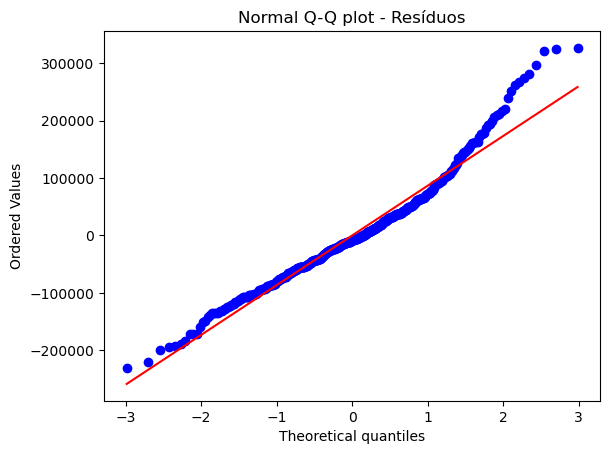

In [120]:
stats.probplot(residuos, dist="norm", plot=plt)
plt.title("Normal Q-Q plot - Resíduos")
plt.show()

In [121]:
estatistica, p = stats.shapiro(residuos)
print('Estatística de teste: {}'.format(estatistica))
print('p-valor: {}'.format(p))

Estatística de teste: 0.9633502378521349
p-valor: 1.087848248956804e-09


#### Análise da Homocedasticidade dos resíduos
(resíduos com variação constante)

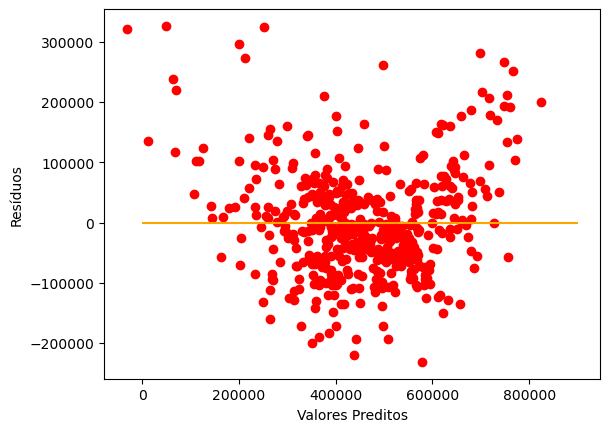

In [122]:
plt.scatter(y=residuos, x=modelo.predict(), color='red')
plt.hlines(y=0, xmin=0, xmax=900000, color='orange')
plt.ylabel('Resíduos')
plt.xlabel('Valores Preditos')
plt.show()

### Teste Breusch-Pagan (Homocedasticidade ou heterocedasticidade)

Ho = existe homocedasticidade : p > 0.05

Ha = não existe homocedasticidade : p <= 0.05

In [123]:
estatistica, p, f, fp = sms.het_breuschpagan (modelo.resid, modelo.model.exog)
print('Estatística de teste: {}'.format(estatistica))
print('p-valor: {}'.format(p))
print('f-valor: {}'.format(f))
print('f_p-valor: {}'.format(fp))

Estatística de teste: 14.86651774115751
p-valor: 0.0019343456956174363
f-valor: 5.069079611723573
f_p-valor: 0.0018260051160027759


#### **Outliers nos resíduos**

(Entre -3 e 3)

In [124]:
outliers = modelo.outlier_test()

In [125]:
outliers.max()

student_resid    3.887418
unadj_p          0.999502
bonf(p)          1.000000
dtype: float64

In [126]:
outliers.min()

student_resid   -2.648018
unadj_p          0.000115
bonf(p)          0.056456
dtype: float64

#### Análise do Modelo

p_valor para cada coeficiente < 0,05 (estatisticamente significativos).

Adjusted R-squared (explicação do modelo através dos dados).

p_valor da estatística F < 0.05 (valida o modelo de regressão).

In [127]:
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.718
Model:                            OLS   Adj. R-squared:                  0.716
Method:                 Least Squares   F-statistic:                     410.9
Date:                Mon, 20 Oct 2025   Prob (F-statistic):          9.96e-133
Time:                        12:42:46   Log-Likelihood:                -6259.9
No. Observations:                 489   AIC:                         1.253e+04
Df Residuals:                     485   BIC:                         1.254e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   4.155e+05   6.88e+04      6.035      0.0

### Equação: Valor da casa = 4.155e+05 + 8.657e+04.RM - 1.085e+04.LSTAT - 1.949e+04.PTRATIO

In [128]:
# Criando uma coluna com previsão
df['previsao'] = modelo.fittedvalues

In [129]:
df.head()

,RM,LSTAT,PTRATIO,MEDV,previsao
0,6.575,4.98,15.3,504000.0,632371.739762
1,6.421,9.14,17.8,453600.0,525177.148313
2,7.185,4.03,17.8,728700.0,646753.118080
3,6.998,2.94,18.7,701400.0,624848.295870
4,7.147,5.33,18.7,760200.0,611816.592536


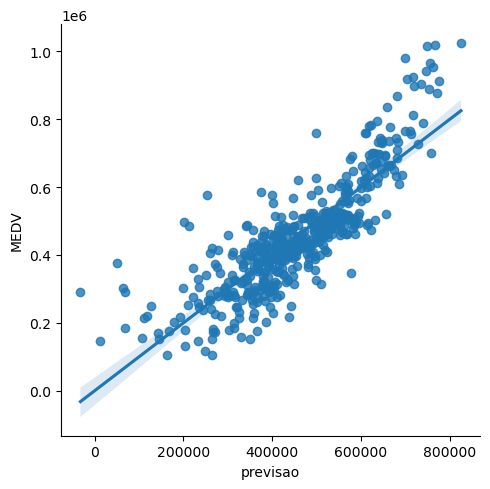

In [130]:
sns.lmplot(x='previsao', y='MEDV', data=df);

## Regressão Polinomial

https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html 

### 1) Valor médio (MEDV) em função do número de cômodos (RM)

In [131]:
df.head(2)

,RM,LSTAT,PTRATIO,MEDV,previsao
0,6.575,4.98,15.3,504000.0,632371.739762
1,6.421,9.14,17.8,453600.0,525177.148313


In [132]:
x1 = df.iloc[:,0:1].values
x1

array([[6.575],
       [6.421],
       [7.185],
       [6.998],
       [7.147],
       [6.43 ],
       [6.012],
       [6.172],
       [5.631],
       [6.004],
       [6.377],
       [6.009],
       [5.889],
       [5.949],
       [6.096],
       [5.834],
       [5.935],
       [5.99 ],
       [5.456],
       [5.727],
       [5.57 ],
       [5.965],
       [6.142],
       [5.813],
       [5.924],
       [5.599],
       [5.813],
       [6.047],
       [6.495],
       [6.674],
       [5.713],
       [6.072],
       [5.95 ],
       [5.701],
       [6.096],
       [5.933],
       [5.841],
       [5.85 ],
       [5.966],
       [6.595],
       [7.024],
       [6.77 ],
       [6.169],
       [6.211],
       [6.069],
       [5.682],
       [5.786],
       [6.03 ],
       [5.399],
       [5.602],
       [5.963],
       [6.115],
       [6.511],
       [5.998],
       [5.888],
       [7.249],
       [6.383],
       [6.816],
       [6.145],
       [5.927],
       [5.741],
       [5.966],
       [

In [133]:
y = df.iloc[:, 3].values
y

array([ 504000.,  453600.,  728700.,  701400.,  760200.,  602700.,
        480900.,  569100.,  346500.,  396900.,  315000.,  396900.,
        455700.,  428400.,  382200.,  417900.,  485100.,  367500.,
        424200.,  382200.,  285600.,  411600.,  319200.,  304500.,
        327600.,  291900.,  348600.,  310800.,  386400.,  441000.,
        266700.,  304500.,  277200.,  275100.,  283500.,  396900.,
        420000.,  441000.,  518700.,  646800.,  732900.,  558600.,
        531300.,  518700.,  445200.,  405300.,  420000.,  348600.,
        302400.,  407400.,  413700.,  430500.,  525000.,  491400.,
        396900.,  743400.,  518700.,  663600.,  489300.,  411600.,
        392700.,  336000.,  466200.,  525000.,  693000.,  493500.,
        407400.,  462000.,  365400.,  438900.,  508200.,  455700.,
        478800.,  491400.,  506100.,  449400.,  420000.,  436800.,
        445200.,  426300.,  588000.,  501900.,  520800.,  480900.,
        501900.,  558600.,  472500.,  466200.,  495600.,  6027

In [134]:
x_treino, x_teste, y_treino, y_teste = train_test_split(x1, y, test_size = 0.3, random_state = 0)

In [135]:
x_treino.shape, y_treino.shape

((342, 1), (342,))

In [136]:
x_teste.shape, y_teste.shape

((147, 1), (147,))

In [137]:
# Pré Processamento
grau_polinomial = PolynomialFeatures(degree=2)

In [138]:
x_poly = grau_polinomial.fit_transform(x_treino)
x_poly

array([[ 1.      ,  6.266   , 39.262756],
       [ 1.      ,  6.951   , 48.316401],
       [ 1.      ,  6.619   , 43.811161],
       ...,
       [ 1.      ,  6.021   , 36.252441],
       [ 1.      ,  6.03    , 36.3609  ],
       [ 1.      ,  6.02    , 36.2404  ]])

In [139]:
polinomial = LinearRegression()

In [140]:
polinomial.fit(x_poly, y_treino)

LinearRegression()

In [141]:
previsoes_treino = polinomial.predict(x_poly)

In [142]:
polinomial.coef_

array([      0.        , -568528.11104731,   60092.59048475])

In [143]:
polinomial.intercept_

np.float64(1640107.0085836374)

**Equação:**

Valor = 1640107 - 568528.11*RM + 60092.59*RM^2

In [144]:
numeros = np.linspace(3,10,342)
numeros

array([ 3.        ,  3.02052786,  3.04105572,  3.06158358,  3.08211144,
        3.1026393 ,  3.12316716,  3.14369501,  3.16422287,  3.18475073,
        3.20527859,  3.22580645,  3.24633431,  3.26686217,  3.28739003,
        3.30791789,  3.32844575,  3.34897361,  3.36950147,  3.39002933,
        3.41055718,  3.43108504,  3.4516129 ,  3.47214076,  3.49266862,
        3.51319648,  3.53372434,  3.5542522 ,  3.57478006,  3.59530792,
        3.61583578,  3.63636364,  3.6568915 ,  3.67741935,  3.69794721,
        3.71847507,  3.73900293,  3.75953079,  3.78005865,  3.80058651,
        3.82111437,  3.84164223,  3.86217009,  3.88269795,  3.90322581,
        3.92375367,  3.94428152,  3.96480938,  3.98533724,  4.0058651 ,
        4.02639296,  4.04692082,  4.06744868,  4.08797654,  4.1085044 ,
        4.12903226,  4.14956012,  4.17008798,  4.19061584,  4.2111437 ,
        4.23167155,  4.25219941,  4.27272727,  4.29325513,  4.31378299,
        4.33431085,  4.35483871,  4.37536657,  4.39589443,  4.41

In [145]:
numeros.shape

(342,)

In [146]:
valor = 1640107 -568528.11*numeros + 60092.59*numeros**2

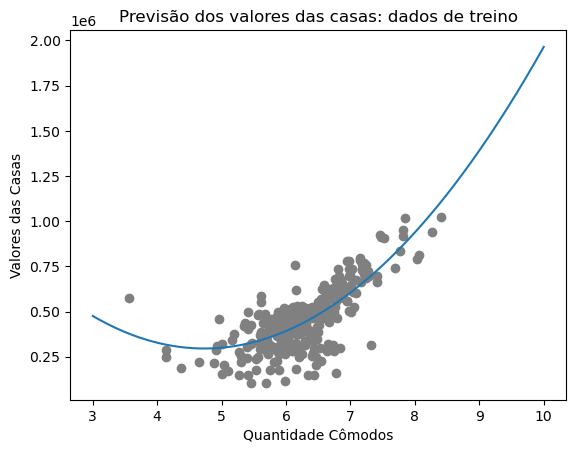

In [147]:
plt.scatter(x_treino, y_treino, c = "gray")
plt.xlabel("Quantidade Cômodos")
plt.ylabel("Valores das Casas")
plt.title("Previsão dos valores das casas: dados de treino")
plt.plot(numeros, valor);

In [148]:
# Fazendo previsões para valores distintos
comodos = 6
valor = 1640107 -568528.11*comodos + 60092.59*comodos**2
valor

392271.5799999996

In [149]:
# Coeficiente de Determinação dados de treino
polinomial.score(x_poly, y_treino)

0.5864656525780776

**TESTE**

In [150]:
numeros2 = np.linspace(3,10,147)
numeros2

array([ 3.        ,  3.04794521,  3.09589041,  3.14383562,  3.19178082,
        3.23972603,  3.28767123,  3.33561644,  3.38356164,  3.43150685,
        3.47945205,  3.52739726,  3.57534247,  3.62328767,  3.67123288,
        3.71917808,  3.76712329,  3.81506849,  3.8630137 ,  3.9109589 ,
        3.95890411,  4.00684932,  4.05479452,  4.10273973,  4.15068493,
        4.19863014,  4.24657534,  4.29452055,  4.34246575,  4.39041096,
        4.43835616,  4.48630137,  4.53424658,  4.58219178,  4.63013699,
        4.67808219,  4.7260274 ,  4.7739726 ,  4.82191781,  4.86986301,
        4.91780822,  4.96575342,  5.01369863,  5.06164384,  5.10958904,
        5.15753425,  5.20547945,  5.25342466,  5.30136986,  5.34931507,
        5.39726027,  5.44520548,  5.49315068,  5.54109589,  5.5890411 ,
        5.6369863 ,  5.68493151,  5.73287671,  5.78082192,  5.82876712,
        5.87671233,  5.92465753,  5.97260274,  6.02054795,  6.06849315,
        6.11643836,  6.16438356,  6.21232877,  6.26027397,  6.30

In [151]:
numeros2.shape

(147,)

In [152]:
valor2 = 1640107 -568528.11*numeros2 + 60092.59*numeros2**2

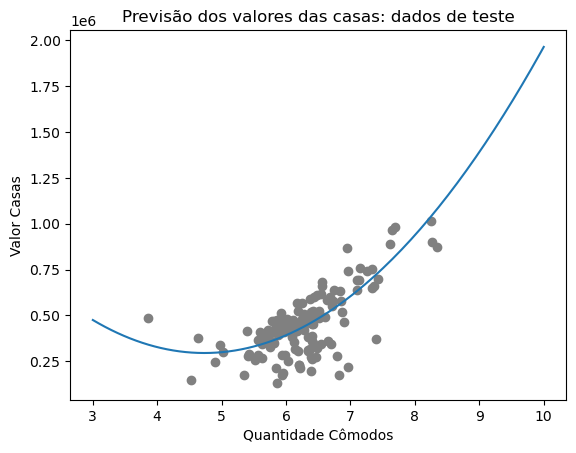

In [153]:
plt.scatter(x_teste, y_teste, c = "gray")
plt.xlabel("Quantidade Cômodos")
plt.ylabel("Valor Casas")
plt.title("Previsão dos valores das casas: dados de teste")
plt.plot(numeros2, valor2);

In [154]:
x_poly_teste = grau_polinomial.fit_transform(x_teste)
x_poly_teste

array([[ 1.      ,  5.834   , 34.035556],
       [ 1.      ,  6.842   , 46.812964],
       [ 1.      ,  5.403   , 29.192409],
       [ 1.      ,  6.852   , 46.949904],
       [ 1.      ,  6.417   , 41.177889],
       [ 1.      ,  6.406   , 41.036836],
       [ 1.      ,  4.903   , 24.039409],
       [ 1.      ,  6.112   , 37.356544],
       [ 1.      ,  6.163   , 37.982569],
       [ 1.      ,  5.965   , 35.581225],
       [ 1.      ,  6.223   , 38.725729],
       [ 1.      ,  5.837   , 34.070569],
       [ 1.      ,  6.041   , 36.493681],
       [ 1.      ,  4.628   , 21.418384],
       [ 1.      ,  6.727   , 45.252529],
       [ 1.      ,  5.757   , 33.143049],
       [ 1.      ,  6.279   , 39.425841],
       [ 1.      ,  6.51    , 42.3801  ],
       [ 1.      ,  5.807   , 33.721249],
       [ 1.      ,  6.739   , 45.414121],
       [ 1.      ,  7.327   , 53.684929],
       [ 1.      ,  7.135   , 50.908225],
       [ 1.      ,  4.519   , 20.421361],
       [ 1.      ,  5.85    , 34.2

In [155]:
polinomial_teste = LinearRegression()

In [156]:
polinomial_teste.fit(x_poly_teste, y_teste)

LinearRegression()

In [157]:
# Coeficiente de Determinação dados de teste
polinomial.score(x_poly_teste, y_teste)

0.5391879530755568

In [158]:
previsoes_teste = polinomial_teste.predict(x_poly_teste)

**MÉTRICAS**

In [159]:
# Erro médio Absoluto
mean_absolute_error(y_teste, previsoes_teste)

88894.00551287523

In [160]:
# Erro quadrático médio
mean_squared_error(y_teste, previsoes_teste)

13149352560.413332

In [161]:
# Raiz do erro quadrático médio (RMSE)
np.sqrt(mean_squared_error(y_teste, previsoes_teste))

np.float64(114670.62640630046)

**RESULTADOS:**

**REGRESSÃO LINEAR SIMPLES:** R^2 = 0,57/0,60; RMSE = 99315,5; R^2 Validação Cruzada: 55,97%

**REGRESSÃO LINEAR MÚLTIPLA:** R^2 = 0,73/0,68; RMSE = 96087,3; R^2 Validação Cruzada: 69,25%

**REGRESSÃO POLINOMIAL:** R^2 = 0,59/0,54; RMSE = 114670,6.

## Regressão por Vetores de Suporte (SVR)

https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVR.html 

In [163]:
independente = df.iloc[:, 0:3].values
independente

array([[ 6.575,  4.98 , 15.3  ],
       [ 6.421,  9.14 , 17.8  ],
       [ 7.185,  4.03 , 17.8  ],
       ...,
       [ 6.976,  5.64 , 21.   ],
       [ 6.794,  6.48 , 21.   ],
       [ 6.03 ,  7.88 , 21.   ]])

In [164]:
independente.shape

(489, 3)

In [165]:
dependente = df.iloc[:, 3].values
dependente

array([ 504000.,  453600.,  728700.,  701400.,  760200.,  602700.,
        480900.,  569100.,  346500.,  396900.,  315000.,  396900.,
        455700.,  428400.,  382200.,  417900.,  485100.,  367500.,
        424200.,  382200.,  285600.,  411600.,  319200.,  304500.,
        327600.,  291900.,  348600.,  310800.,  386400.,  441000.,
        266700.,  304500.,  277200.,  275100.,  283500.,  396900.,
        420000.,  441000.,  518700.,  646800.,  732900.,  558600.,
        531300.,  518700.,  445200.,  405300.,  420000.,  348600.,
        302400.,  407400.,  413700.,  430500.,  525000.,  491400.,
        396900.,  743400.,  518700.,  663600.,  489300.,  411600.,
        392700.,  336000.,  466200.,  525000.,  693000.,  493500.,
        407400.,  462000.,  365400.,  438900.,  508200.,  455700.,
        478800.,  491400.,  506100.,  449400.,  420000.,  436800.,
        445200.,  426300.,  588000.,  501900.,  520800.,  480900.,
        501900.,  558600.,  472500.,  466200.,  495600.,  6027

In [166]:
x_treino, x_teste, y_treino, y_teste = train_test_split(independente, dependente, test_size = 0.3, random_state = 0)

In [167]:
x_treino.shape, x_teste.shape

((342, 3), (147, 3))

In [168]:
# kernel = rbf, linear, polinomial (poly)
from sklearn.svm import SVR
SVR = SVR(kernel='rbf')
SVR.fit(x_treino,y_treino)

SVR()

In [169]:
SVR.score(x_treino, y_treino)

-0.006148700884580638

In [170]:
SVR.score(x_teste, y_teste)

-0.0029977270958452262

In [171]:
# Valores péssimos de score, não usar esse modelo

**Padronização de escala**: visto que SVR é um modelo baseado em distância

In [172]:
x_scaler = StandardScaler()
x_treino_scaler = x_scaler.fit_transform(x_treino)

In [173]:
x_treino_scaler

array([[ 0.05327517, -0.70150711, -0.05467118],
       [ 1.12799963, -0.44487061, -0.52922816],
       [ 0.60711128, -0.79792304,  0.230063  ],
       ...,
       [-0.33111532, -0.36121561, -0.33940537],
       [-0.31699486,  0.84398345, -0.29194967],
       [-0.33268427, -0.38815536, -0.90887374]])

In [174]:
y_scaler = StandardScaler()
y_treino_scaler = y_scaler.fit_transform(y_treino.reshape(-1,1))

In [175]:
y_treino_scaler

array([[-1.05925606e-02],
       [ 6.46900118e-01],
       [ 2.85923746e-01],
       [-1.13728667e-01],
       [ 1.44111599e-01],
       [-7.84113359e-01],
       [-1.24822584e+00],
       [-2.81324840e-01],
       [-1.39512694e-01],
       [-1.01616960e+00],
       [ 2.00056152e+00],
       [ 1.21414870e+00],
       [ 1.27860877e+00],
       [-1.52404707e-01],
       [ 9.04740384e-01],
       [ 2.29945267e-03],
       [-2.81324840e-01],
       [ 2.73031732e-01],
       [-2.81324840e-01],
       [ 2.73031732e-01],
       [ 4.27735892e-01],
       [ 2.60139719e-01],
       [-1.06773765e+00],
       [-1.17087376e+00],
       [ 3.49603506e+00],
       [ 9.04740384e-01],
       [-2.07331469e+00],
       [ 1.69895626e-01],
       [ 4.27735892e-01],
       [ 2.76119030e+00],
       [-3.45784907e-01],
       [ 2.73031732e-01],
       [-1.48028208e+00],
       [ 1.57003612e-01],
       [-1.91080747e-01],
       [-1.01616960e+00],
       [ 3.37491799e-01],
       [-2.34845740e-02],
       [ 1.9

In [176]:
x_teste_scaler = x_scaler.transform(x_teste)
x_teste_scaler

array([[-6.24507256e-01, -6.20687880e-01,  1.17917695e+00],
       [ 9.56985082e-01, -8.43295235e-01, -2.61727885e+00],
       [-1.30072075e+00,  1.98112421e+00, -1.81053199e+00],
       [ 9.72674490e-01,  9.82935809e-01,  7.99531373e-01],
       [ 2.90185237e-01, -5.72479917e-01, -3.39405369e-01],
       [ 2.72926888e-01,  9.46070896e-01,  7.99531373e-01],
       [-2.08519115e+00,  2.33134087e+00, -1.81053199e+00],
       [-1.88341711e-01, -2.51777567e-02,  7.99531373e-01],
       [-1.08325729e-01, -2.13755962e-01, -2.44493974e-01],
       [-4.18976010e-01,  1.39296468e-01,  1.17917695e+00],
       [-1.41892805e-02,  1.26651206e+00,  7.99531373e-01],
       [-6.19800434e-01,  4.03022379e-01,  7.99531373e-01],
       [-2.99736508e-01, -7.29864736e-01,  5.14797187e-01],
       [-2.51664988e+00,  3.05162455e+00,  7.99531373e-01],
       [ 7.76556889e-01, -4.85989161e-01,  1.13172126e+00],
       [-7.45315699e-01,  6.32719141e-01,  1.27408835e+00],
       [ 7.36714050e-02, -1.24429444e-01

In [177]:
y_teste_scaler = y_scaler.transform(y_teste.reshape(-1,1))
y_teste_scaler

array([[-2.29756787e-01],
       [ 1.08522857e+00],
       [-1.06773765e+00],
       [ 7.50036225e-01],
       [ 1.18327572e-01],
       [-5.90733160e-01],
       [-1.27400987e+00],
       [ 1.18327572e-01],
       [-3.63765873e-02],
       [-2.68432827e-01],
       [-1.48028208e+00],
       [-1.48028208e+00],
       [-1.65296720e-01],
       [-4.87597053e-01],
       [ 7.50036225e-01],
       [-7.84113359e-01],
       [-2.16864774e-01],
       [ 2.08571666e-01],
       [ 9.25435458e-02],
       [ 1.13679662e+00],
       [ 1.20125669e+00],
       [ 1.44620494e+00],
       [-1.89282650e+00],
       [-8.79446405e-02],
       [-5.39165106e-01],
       [ 3.13505869e+00],
       [ 1.84585736e+00],
       [ 2.65805419e+00],
       [ 2.29945267e-03],
       [-6.21606139e-02],
       [-8.09897386e-01],
       [ 2.29945267e-03],
       [-1.52404707e-01],
       [ 2.52913406e+00],
       [-6.21606139e-02],
       [ 2.58070211e+00],
       [-2.42648800e-01],
       [-1.14508973e+00],
       [ 8.2

In [178]:
from sklearn.svm import SVR

SVR2 = SVR(kernel='rbf')
SVR2.fit(x_treino_scaler, y_treino_scaler.ravel())   # .ravel() é para retornar matriz 1D

SVR()

In [179]:
SVR2.score(x_treino_scaler, y_treino_scaler)

0.8714780218682298

In [181]:
SVR2.score(x_teste_scaler, y_teste_scaler)

0.814196348071232

In [180]:
# Valores de R^2 muito melhores após o escalonamento dos dados.

In [182]:
previsoes_teste = SVR2.predict(x_teste_scaler)
previsoes_teste

array([-2.15791224e-01,  1.10142277e+00, -6.88494535e-01, -1.07563769e+00,
        3.01247352e-01, -9.98869785e-01, -5.59722487e-01, -2.77421653e-01,
       -2.73937823e-02, -4.12691897e-01, -1.16997042e+00, -5.18534667e-01,
       -2.21332947e-02, -1.40012104e+00,  2.00513309e-02, -7.36008350e-01,
       -6.93655466e-02,  5.92234013e-01, -2.48820576e-01,  1.07290408e+00,
        1.76335951e+00,  1.75215955e+00, -1.13186294e+00, -9.89244717e-02,
       -2.62519149e-01,  2.76202189e+00,  1.95334571e+00,  2.71163016e+00,
       -3.10648675e-01, -2.12642736e-01, -9.48038395e-01, -3.73399265e-01,
        1.92487075e-03,  1.41767802e+00, -1.05707405e-01,  2.19221752e+00,
        6.84125100e-02, -1.21422076e+00,  1.73245025e-01,  5.77702833e-01,
       -1.14127434e+00, -3.64357403e-01, -2.10842559e-01,  1.39103054e-01,
       -6.03862563e-01, -4.32397688e-01,  2.77358169e-01, -7.89247973e-01,
        1.58912076e+00, -2.49546698e-01,  1.47592810e+00, -1.13924390e-01,
        8.76296120e-01, -

In [183]:
y_teste_scaler

array([[-2.29756787e-01],
       [ 1.08522857e+00],
       [-1.06773765e+00],
       [ 7.50036225e-01],
       [ 1.18327572e-01],
       [-5.90733160e-01],
       [-1.27400987e+00],
       [ 1.18327572e-01],
       [-3.63765873e-02],
       [-2.68432827e-01],
       [-1.48028208e+00],
       [-1.48028208e+00],
       [-1.65296720e-01],
       [-4.87597053e-01],
       [ 7.50036225e-01],
       [-7.84113359e-01],
       [-2.16864774e-01],
       [ 2.08571666e-01],
       [ 9.25435458e-02],
       [ 1.13679662e+00],
       [ 1.20125669e+00],
       [ 1.44620494e+00],
       [-1.89282650e+00],
       [-8.79446405e-02],
       [-5.39165106e-01],
       [ 3.13505869e+00],
       [ 1.84585736e+00],
       [ 2.65805419e+00],
       [ 2.29945267e-03],
       [-6.21606139e-02],
       [-8.09897386e-01],
       [ 2.29945267e-03],
       [-1.52404707e-01],
       [ 2.52913406e+00],
       [-6.21606139e-02],
       [ 2.58070211e+00],
       [-2.42648800e-01],
       [-1.14508973e+00],
       [ 8.2

**Revertendo a transformação**

In [184]:
y_teste_inverse = y_scaler.inverse_transform(y_teste_scaler)
previsoes_inverse = y_scaler.inverse_transform(previsoes_teste.reshape(-1, 1))

In [185]:
y_teste_inverse

array([[ 417900.],
       [ 632100.],
       [ 281400.],
       [ 577500.],
       [ 474600.],
       [ 359100.],
       [ 247800.],
       [ 474600.],
       [ 449400.],
       [ 411600.],
       [ 214200.],
       [ 214200.],
       [ 428400.],
       [ 375900.],
       [ 577500.],
       [ 327600.],
       [ 420000.],
       [ 489300.],
       [ 470400.],
       [ 640500.],
       [ 651000.],
       [ 690900.],
       [ 147000.],
       [ 441000.],
       [ 367500.],
       [ 966000.],
       [ 756000.],
       [ 888300.],
       [ 455700.],
       [ 445200.],
       [ 323400.],
       [ 455700.],
       [ 430500.],
       [ 867300.],
       [ 445200.],
       [ 875700.],
       [ 415800.],
       [ 268800.],
       [ 590100.],
       [ 497700.],
       [ 231000.],
       [ 315000.],
       [ 388500.],
       [ 449400.],
       [ 413700.],
       [ 352800.],
       [ 453600.],
       [ 306600.],
       [ 898800.],
       [ 514500.],
       [ 743400.],
       [ 474600.],
       [ 600

In [186]:
previsoes_inverse

array([[420174.87212807],
       [634737.89796179],
       [343175.49828345],
       [280113.15005471],
       [504396.08603148],
       [292617.99343947],
       [364151.37652378],
       [410135.79618577],
       [450863.2230036 ],
       [388101.41673155],
       [264747.14617165],
       [370860.52420003],
       [451720.11197717],
       [227257.55557269],
       [458591.63091728],
       [335435.89942756],
       [444026.37735555],
       [551795.35352618],
       [414794.66988335],
       [630092.44529088],
       [742561.7980311 ],
       [740737.41964992],
       [270954.53338452],
       [439211.47830344],
       [412563.2881634 ],
       [905235.45836988],
       [773508.94404311],
       [897027.07241   ],
       [404723.39514996],
       [420687.73421742],
       [300897.99727853],
       [394501.85450868],
       [455638.98377251],
       [686253.20534829],
       [438106.59583664],
       [812419.14319062],
       [466469.25822128],
       [257539.14000176],
       [4835

### Métricas de Desempenho

In [187]:
# Erro médio Absoluto
mean_absolute_error(y_teste_inverse, previsoes_inverse)

54733.89949882337

In [188]:
# Erro quadrático médio
mean_squared_error(y_teste_inverse, previsoes_inverse)

5390892216.930899

In [189]:
# Raiz do erro quadrático médio (RMSE)
np.sqrt(mean_squared_error(y_teste_inverse, previsoes_inverse))

np.float64(73422.69551665138)

### **Validação Cruzada**

**Padronização de escala**

In [190]:
x = StandardScaler()
independente_scaler = x.fit_transform(independente)

In [191]:
independente_scaler

array([[ 0.52055395, -1.1250769 , -1.5250831 ],
       [ 0.28104837, -0.53706982, -0.33974768],
       [ 1.46924486, -1.25935736, -0.33974768],
       ...,
       [ 1.14420158, -1.03178731,  1.17748167],
       [ 0.86114953, -0.91305511,  1.17748167],
       [-0.32704695, -0.71516812,  1.17748167]])

In [192]:
y = StandardScaler()
dependente_scaler = y.fit_transform(dependente.reshape(-1,1))

In [193]:
# Separando os dados em folds
kfold = KFold(n_splits = 15, shuffle=True, random_state = 5)

In [194]:
# Criando o modelo
modelo = SVR(kernel='rbf')
resultado = cross_val_score(modelo, independente_scaler, dependente_scaler.ravel(), cv = kfold)
resultado

array([0.92812888, 0.84684121, 0.77550142, 0.84579676, 0.87130224,
       0.73027848, 0.8773257 , 0.8323081 , 0.81165058, 0.86738849,
       0.91428868, 0.65473478, 0.78365184, 0.83876782, 0.77741225])

In [195]:
# Média do coef de determinação da validação cruzada
print("Coeficiente de Determinação médio: %.2f%%" % (resultado.mean() * 100.0))

Coeficiente de Determinação médio: 82.37%


**RESULTADOS:**

**REGRESSÃO LINEAR SIMPLES:** R^2 = 0,57/0,60; RMSE = 99315,5; R^2 Validação Cruzada: 55,97%

**REGRESSÃO LINEAR MÚLTIPLA:** R^2 = 0,73/0,68; RMSE = 96087,3; R^2 Validação Cruzada: 69,25%

**REGRESSÃO POLINOMIAL:** R^2 = 0,59/0,54; RMSE = 114670,6.

**REGRESSÃO SVR:** R^2 = 0,87/0,81; RMSE = 73422,7. R^2 Validação Cruzada: 82,37%.

## Regressão com Árvores de Decisão

https://scikit-learn.org/stable/modules/tree.html#regression 

In [196]:
df.head(2)

,RM,LSTAT,PTRATIO,MEDV,previsao
0,6.575,4.98,15.3,504000.0,632371.739762
1,6.421,9.14,17.8,453600.0,525177.148313


In [197]:
independente = df.iloc[:, 0:3].values
independente

array([[ 6.575,  4.98 , 15.3  ],
       [ 6.421,  9.14 , 17.8  ],
       [ 7.185,  4.03 , 17.8  ],
       ...,
       [ 6.976,  5.64 , 21.   ],
       [ 6.794,  6.48 , 21.   ],
       [ 6.03 ,  7.88 , 21.   ]])

In [198]:
independente.shape

(489, 3)

In [199]:
dependente = df.iloc[:, 3].values
dependente

array([ 504000.,  453600.,  728700.,  701400.,  760200.,  602700.,
        480900.,  569100.,  346500.,  396900.,  315000.,  396900.,
        455700.,  428400.,  382200.,  417900.,  485100.,  367500.,
        424200.,  382200.,  285600.,  411600.,  319200.,  304500.,
        327600.,  291900.,  348600.,  310800.,  386400.,  441000.,
        266700.,  304500.,  277200.,  275100.,  283500.,  396900.,
        420000.,  441000.,  518700.,  646800.,  732900.,  558600.,
        531300.,  518700.,  445200.,  405300.,  420000.,  348600.,
        302400.,  407400.,  413700.,  430500.,  525000.,  491400.,
        396900.,  743400.,  518700.,  663600.,  489300.,  411600.,
        392700.,  336000.,  466200.,  525000.,  693000.,  493500.,
        407400.,  462000.,  365400.,  438900.,  508200.,  455700.,
        478800.,  491400.,  506100.,  449400.,  420000.,  436800.,
        445200.,  426300.,  588000.,  501900.,  520800.,  480900.,
        501900.,  558600.,  472500.,  466200.,  495600.,  6027

In [200]:
dependente.shape

(489,)

In [201]:
x_treino, x_teste, y_treino, y_teste = train_test_split(independente, dependente, test_size = 0.3, random_state = 0)

In [202]:
x_treino.shape, x_teste.shape

((342, 3), (147, 3))

In [203]:
y_treino.shape, y_teste.shape

((342,), (147,))

In [204]:
arvore = DecisionTreeRegressor(max_depth=5, random_state=10)
arvore.fit(x_treino, y_treino)

DecisionTreeRegressor(max_depth=5, random_state=10)

In [205]:
arvore.score(x_treino, y_treino)

0.9050951127606555

In [206]:
arvore.score(x_teste, y_teste)

0.8256951550328737

In [207]:
previsoes_teste = arvore.predict(x_teste)
previsoes_teste

array([449000.        , 597187.5       , 311850.        , 296100.        ,
       507223.25581395, 313740.        , 340200.        , 408900.        ,
       454268.18181818, 408900.        , 245855.55555556, 313740.        ,
       449000.        , 193760.        , 529433.33333333, 348600.        ,
       454268.18181818, 507223.25581395, 411075.        , 598823.07692308,
       715130.76923077, 789600.        , 193760.        , 449000.        ,
       411075.        , 914200.        , 715130.76923077, 914200.        ,
       408900.        , 408900.        , 313740.        , 411075.        ,
       408900.        , 688380.        , 454268.18181818, 940800.        ,
       507223.25581395, 245855.55555556, 507223.25581395, 507223.25581395,
       245855.55555556, 411075.        , 453000.        , 507223.25581395,
       411075.        , 408900.        , 507223.25581395, 313740.        ,
       940800.        , 408900.        , 688380.        , 454268.18181818,
       598823.07692308, 3

In [208]:
y_teste

array([ 417900.,  632100.,  281400.,  577500.,  474600.,  359100.,
        247800.,  474600.,  449400.,  411600.,  214200.,  214200.,
        428400.,  375900.,  577500.,  327600.,  420000.,  489300.,
        470400.,  640500.,  651000.,  690900.,  147000.,  441000.,
        367500.,  966000.,  756000.,  888300.,  455700.,  445200.,
        323400.,  455700.,  430500.,  867300.,  445200.,  875700.,
        415800.,  268800.,  590100.,  497700.,  231000.,  315000.,
        388500.,  449400.,  413700.,  352800.,  453600.,  306600.,
        898800.,  514500.,  743400.,  474600.,  600600.,  304500.,
        661500.,  489300.,  422100.,  184800.,  525000.,  249900.,
        407400.,  361200.,  428400.,  392700.,  428400.,  472500.,
        258300.,  550200.,  346500.,  199500.,  302400.,  611100.,
        396900.,  585900.,  279300.,  483000.,  462000.,  218400.,
        518700.,  420000.,  392700.,  980700.,  455700.,  514500.,
        480900.,  520800.,  485100.,  525000.,  390600.,  5691

### Métricas de Desempenho

In [209]:
# Erro médio Absoluto
mean_absolute_error(y_teste, previsoes_teste)

52954.00426293284

In [210]:
# Erro quadrático médio
mean_squared_error(y_teste, previsoes_teste)

5057266756.343771

In [211]:
# Raiz do erro quadrático médio (RMSE)
np.sqrt(mean_squared_error(y_teste, previsoes_teste))

np.float64(71114.46235713077)

### **Validação Cruzada**

In [212]:
# Separando os dados em folds
kfold = KFold(n_splits = 15, shuffle=True, random_state = 5)

In [213]:
# Criando o modelo
modelo = DecisionTreeRegressor(max_depth=5, random_state=10)
resultado = cross_val_score(modelo, independente, dependente, cv = kfold)
resultado

array([0.9107871 , 0.91994845, 0.70416127, 0.79571349, 0.64537243,
       0.62424022, 0.83188854, 0.77916943, 0.74608406, 0.45125985,
       0.92525406, 0.72678715, 0.72120525, 0.84170908, 0.56581873])

In [214]:
# Coeficiente de Determinação Médio da validação cruzada
print("Coeficiente de Determinação Médio: %.2f%%" % (resultado.mean() * 100.0))

Coeficiente de Determinação Médio: 74.60%


**RESULTADOS:**

**REGRESSÃO LINEAR SIMPLES:** R^2 = 0,57/0,60; RMSE = 99315,5; R^2 Validação Cruzada: 55,97%

**REGRESSÃO LINEAR MÚLTIPLA:** R^2 = 0,73/0,68; RMSE = 96087,3; R^2 Validação Cruzada: 69,25%

**REGRESSÃO POLINOMIAL:** R^2 = 0,59/0,54; RMSE = 114670,6.

**REGRESSÃO SVR:** R^2 = 0,87/0,81; RMSE = 73422,7. R^2 Validação Cruzada: 82,37%.

**REGRESSÃO ÁRVORE DE DECISÃO:** R^2 = 0,91/0,83; RMSE = 71114,5. R^2 Validação Cruzada: 74,60%.

## Regressão com Random Forest

https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html 

In [216]:
independente = df.iloc[:, 0:3].values
independente

array([[ 6.575,  4.98 , 15.3  ],
       [ 6.421,  9.14 , 17.8  ],
       [ 7.185,  4.03 , 17.8  ],
       ...,
       [ 6.976,  5.64 , 21.   ],
       [ 6.794,  6.48 , 21.   ],
       [ 6.03 ,  7.88 , 21.   ]])

In [218]:
dependente = df.iloc[:, 3].values
dependente

array([ 504000.,  453600.,  728700.,  701400.,  760200.,  602700.,
        480900.,  569100.,  346500.,  396900.,  315000.,  396900.,
        455700.,  428400.,  382200.,  417900.,  485100.,  367500.,
        424200.,  382200.,  285600.,  411600.,  319200.,  304500.,
        327600.,  291900.,  348600.,  310800.,  386400.,  441000.,
        266700.,  304500.,  277200.,  275100.,  283500.,  396900.,
        420000.,  441000.,  518700.,  646800.,  732900.,  558600.,
        531300.,  518700.,  445200.,  405300.,  420000.,  348600.,
        302400.,  407400.,  413700.,  430500.,  525000.,  491400.,
        396900.,  743400.,  518700.,  663600.,  489300.,  411600.,
        392700.,  336000.,  466200.,  525000.,  693000.,  493500.,
        407400.,  462000.,  365400.,  438900.,  508200.,  455700.,
        478800.,  491400.,  506100.,  449400.,  420000.,  436800.,
        445200.,  426300.,  588000.,  501900.,  520800.,  480900.,
        501900.,  558600.,  472500.,  466200.,  495600.,  6027

In [217]:
independente.shape

(489, 3)

In [219]:
dependente.shape

(489,)

In [220]:
x_treino, x_teste, y_treino, y_teste = train_test_split(independente, dependente, test_size = 0.3, random_state = 0)

In [221]:
x_treino.shape, x_teste.shape

((342, 3), (147, 3))

In [222]:
y_treino.shape, y_teste.shape

((342,), (147,))

In [223]:
random = RandomForestRegressor(n_estimators=60, criterion='squared_error', max_depth=5, random_state = 10)
random.fit(x_treino, y_treino)

RandomForestRegressor(max_depth=5, n_estimators=60, random_state=10)

In [224]:
random.score(x_treino, y_treino)

0.9160346630571496

In [225]:
random.score(x_teste, y_teste)

0.8465287311346861

In [226]:
previsoes_teste = random.predict(x_teste)
previsoes_teste

array([429790.1184383 , 626425.24570752, 319291.        , 369687.79212278,
       504007.08094948, 275038.77411657, 325784.08333333, 419935.2164072 ,
       461145.73252911, 407252.93004329, 250872.39578869, 342808.74084789,
       454388.83705035, 207628.59742739, 523389.0588747 , 343148.06749092,
       436277.53376586, 519168.2986373 , 400302.89135561, 591299.21535976,
       617998.62691853, 737021.36549068, 207628.59742739, 433990.65598718,
       378602.16484354, 911394.60227273, 690510.8130319 , 913862.10227273,
       420589.43787112, 423405.52420844, 326646.08924392, 380183.19387172,
       436732.30908567, 687715.29521126, 434483.34195931, 890163.5       ,
       529306.19369936, 231323.99610428, 491146.52058414, 505014.08035269,
       256106.89211222, 382749.3212387 , 424659.14608592, 488901.56840275,
       401002.16125623, 406066.93224785, 503825.27539393, 325390.61402888,
       856473.33333333, 421515.20723289, 693269.282585  , 434272.60667474,
       558379.53436472, 3

In [227]:
y_teste

array([ 417900.,  632100.,  281400.,  577500.,  474600.,  359100.,
        247800.,  474600.,  449400.,  411600.,  214200.,  214200.,
        428400.,  375900.,  577500.,  327600.,  420000.,  489300.,
        470400.,  640500.,  651000.,  690900.,  147000.,  441000.,
        367500.,  966000.,  756000.,  888300.,  455700.,  445200.,
        323400.,  455700.,  430500.,  867300.,  445200.,  875700.,
        415800.,  268800.,  590100.,  497700.,  231000.,  315000.,
        388500.,  449400.,  413700.,  352800.,  453600.,  306600.,
        898800.,  514500.,  743400.,  474600.,  600600.,  304500.,
        661500.,  489300.,  422100.,  184800.,  525000.,  249900.,
        407400.,  361200.,  428400.,  392700.,  428400.,  472500.,
        258300.,  550200.,  346500.,  199500.,  302400.,  611100.,
        396900.,  585900.,  279300.,  483000.,  462000.,  218400.,
        518700.,  420000.,  392700.,  980700.,  455700.,  514500.,
        480900.,  520800.,  485100.,  525000.,  390600.,  5691

### Métricas de Desempenho

In [228]:
# Erro médio Absoluto
mean_absolute_error(y_teste, previsoes_teste)

49730.29595322481

In [229]:
# Erro quadrático médio
mean_squared_error(y_teste, previsoes_teste)

4452803054.515374

In [230]:
# Raiz do erro quadrático médio (RMSE)
np.sqrt(mean_squared_error(y_teste, previsoes_teste))

np.float64(66729.326795011)

### **Validação Cruzada**

In [231]:
# Separando os dados em folds
kfold = KFold(n_splits = 15, shuffle=True, random_state = 5)

In [ ]:
# Criando o modelo
modelo = RandomForestRegressor(n_estimators=60, criterion='squared_error', max_depth=5, random_state = 10)
resultado = cross_val_score(modelo, independente, dependente, cv = kfold)
resultado

array([0.9390087 , 0.9048205 , 0.78576987, 0.78178487, 0.80471035,
       0.73189206, 0.88019637, 0.85442545, 0.7796746 , 0.82002933,
       0.93538902, 0.72717569, 0.80683864, 0.8863317 , 0.78974059])

In [233]:
# Coeficiente de Determinação Médio da validação cruzada
print("Coeficiente de Determinação Médio: %.2f%%" % (resultado.mean() * 100.0))

Coeficiente de Determinação Médio: 82.85%


**RESULTADOS:**

**REGRESSÃO LINEAR SIMPLES:** R^2 = 0,57/0,60; RMSE = 99315,5; R^2 Validação Cruzada: 55,97%

**REGRESSÃO LINEAR MÚLTIPLA:** R^2 = 0,73/0,68; RMSE = 96087,3; R^2 Validação Cruzada: 69,25%

**REGRESSÃO POLINOMIAL:** R^2 = 0,59/0,54; RMSE = 114670,6.

**REGRESSÃO SVR:** R^2 = 0,87/0,81; RMSE = 73422,7. R^2 Validação Cruzada: 82,37%.

**REGRESSÃO ÁRVORE DE DECISÃO:** R^2 = 0,91/0,83; RMSE = 71114,5. R^2 Validação Cruzada: 74,60%.

**REGRESSÃO COM RANDOM FOREST:** R^2 = 0,92/0,85; RMSE = 66729,3. R^2 Validação Cruzada: 82,85%.

## Regressão com XGBoost

https://xgboost.readthedocs.io/en/latest/python/python_api.html#xgboost.XGBRegressor 

In [235]:
independente = df.iloc[:, 0:3].values
independente

array([[ 6.575,  4.98 , 15.3  ],
       [ 6.421,  9.14 , 17.8  ],
       [ 7.185,  4.03 , 17.8  ],
       ...,
       [ 6.976,  5.64 , 21.   ],
       [ 6.794,  6.48 , 21.   ],
       [ 6.03 ,  7.88 , 21.   ]])

In [237]:
dependente = df.iloc[:, 3].values

In [236]:
independente.shape

(489, 3)

In [238]:
dependente.shape

(489,)

In [239]:
x_treino, x_teste, y_treino, y_teste = train_test_split(independente, dependente, test_size = 0.3, random_state = 0)

In [240]:
x_treino.shape, x_teste.shape

((342, 3), (147, 3))

In [241]:
xgboost = XGBRegressor(n_estimators=180, max_depth=3, learning_rate=0.05, objective="reg:squarederror", random_state=10)
xgboost.fit(x_treino, y_treino)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=180,
             n_jobs=None, num_parallel_tree=None, ...)

In [242]:
xgboost.score(x_treino, y_treino)

0.9289110382362605

In [243]:
xgboost.score(x_teste, y_teste)

0.8395066646498099

In [244]:
previsoes_teste = xgboost.predict(x_teste)

In [245]:
# Fazendo previsões para valores distintos
valor_casa = xgboost.predict([[6,20,12]])
valor_casa

array([356100.6], dtype=float32)


### Métricas de Desempenho

In [246]:
# Erro médio Absoluto
mean_absolute_error(y_teste, previsoes_teste)

51564.748830782315

In [247]:
# Raiz do erro quadrático médio (RMSE)
np.sqrt(mean_squared_error(y_teste, previsoes_teste))

np.float64(68238.85056825109)

### Validação Cruzada

In [248]:
# Separando os dados em folds
kfold = KFold(n_splits = 15, shuffle=True, random_state = 5)

In [ ]:
# Criando o modelo
modelo = XGBRegressor(n_estimators=180, max_depth=3, learning_rate=0.05, objective = "reg:squarederror")
resultado = cross_val_score(modelo, independente, dependente, cv = kfold)
resultado

array([0.9151535 , 0.90873767, 0.77263186, 0.80988912, 0.84544355,
       0.73201005, 0.91066964, 0.82575379, 0.82342746, 0.85921785,
       0.92123404, 0.70669457, 0.76360029, 0.8708078 , 0.80668477])

In [250]:
# Coeficiente de Determinação Médio da validação cruzada
print("Coeficiente de determinação Médio: %.2f%%" % (resultado.mean() * 100.0))

Coeficiente de determinação Médio: 83.15%


**RESULTADOS:**

**REGRESSÃO LINEAR SIMPLES:** R^2 = 0,57/0,60; RMSE = 99315,5; R^2 Validação Cruzada: 55,97%

**REGRESSÃO LINEAR MÚLTIPLA:** R^2 = 0,73/0,68; RMSE = 96087,3; R^2 Validação Cruzada: 69,25%

**REGRESSÃO POLINOMIAL:** R^2 = 0,59/0,54; RMSE = 114670,6.

**REGRESSÃO SVR:** R^2 = 0,87/0,81; RMSE = 73422,7. R^2 Validação Cruzada: 82,37%.

**REGRESSÃO ÁRVORE DE DECISÃO:** R^2 = 0,91/0,83; RMSE = 71114,5. R^2 Validação Cruzada: 74,60%.

**REGRESSÃO COM RANDOM FOREST:** R^2 = 0,92/0,85; RMSE = 66729,3. R^2 Validação Cruzada: 82,85%.

**REGRESSÃO COM XGBOOST:** R^2 = 0,93/0,84; RMSE = 67788,8. R^2 Validação Cruzada: 83,22%.

## Regressão com LightGBM

https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMRegressor.html 

In [252]:
independente = df.iloc[:, 0:3].values
independente

array([[ 6.575,  4.98 , 15.3  ],
       [ 6.421,  9.14 , 17.8  ],
       [ 7.185,  4.03 , 17.8  ],
       ...,
       [ 6.976,  5.64 , 21.   ],
       [ 6.794,  6.48 , 21.   ],
       [ 6.03 ,  7.88 , 21.   ]])

In [254]:
dependente = df.iloc[:, 3].values

In [253]:
independente.shape

(489, 3)

In [255]:
dependente.shape

(489,)

In [256]:
x_treino, x_teste, y_treino, y_teste = train_test_split(independente, dependente, test_size = 0.3, random_state = 0)

In [257]:
x_treino.shape, x_teste.shape

((342, 3), (147, 3))

In [258]:
lgbm = lgb.LGBMRegressor(num_leaves=50, max_depth=3, learning_rate=0.1, n_estimators=50, random_state=10)
lgbm.fit(x_treino, y_treino)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000071 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 266
[LightGBM] [Info] Number of data points in the train set: 342, number of used features: 3
[LightGBM] [Info] Start training from score 455325.438596
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

c:\Users\mau_a\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning:

Could not find the number of physical cores for the following reason:
[WinError 2] O sistema não pode encontrar o arquivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.

  File "c:\Users\mau_a\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\mau_a\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\mau_a\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^

LGBMRegressor(max_depth=3, n_estimators=50, num_leaves=50, random_state=10)

In [259]:
lgbm.score(x_treino, y_treino)

c:\Users\mau_a\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMRegressor was fitted with feature names



0.8814914688459106

In [260]:
lgbm.score(x_teste, y_teste)

c:\Users\mau_a\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMRegressor was fitted with feature names



0.821790912114666

In [261]:
previsoes_teste = lgbm.predict(x_teste)

c:\Users\mau_a\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMRegressor was fitted with feature names



In [262]:
# Fazendo previsões para valores distintos
valor_casa = lgbm.predict([[8,12,25]])
valor_casa

c:\Users\mau_a\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMRegressor was fitted with feature names



array([473777.6547499])

### Métricas de Desempenho

In [263]:
# Erro médio Absoluto
mean_absolute_error(y_teste, previsoes_teste)

55114.09314449551

In [264]:
# Raiz do erro quadrático médio (RMSE)
np.sqrt(mean_squared_error(y_teste, previsoes_teste))

np.float64(71906.49585704789)

### Validação Cruzada

In [265]:
# Separando os dados em folds
kfold = KFold(n_splits = 15, shuffle=True, random_state = 5)

In [266]:
# Criando o modelo
modelo = lgb.LGBMRegressor(num_leaves=50, max_depth=3, learning_rate=0.1, n_estimators=50)
resultado = cross_val_score(modelo, independente, dependente, cv = kfold)
resultado

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000048 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 344
[LightGBM] [Info] Number of data points in the train set: 456, number of used features: 3
[LightGBM] [Info] Start training from score 454092.763158
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

c:\Users\mau_a\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMRegressor was fitted with feature names

c:\Users\mau_a\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMRegressor was fitted with feature names

c:\Users\mau_a\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMRegressor was fitted with feature names

c:\Users\mau_a\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMRegressor was fitted with feature names

c:\Users\mau_a\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMRegressor was fitted with feature names

c:\Users\mau_a\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning:

X does not have valid fe

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

c:\Users\mau_a\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMRegressor was fitted with feature names

c:\Users\mau_a\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMRegressor was fitted with feature names

c:\Users\mau_a\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMRegressor was fitted with feature names

c:\Users\mau_a\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMRegressor was fitted with feature names

c:\Users\mau_a\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMRegressor was fitted with feature names



[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000032 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 344
[LightGBM] [Info] Number of data points in the train set: 457, number of used features: 3
[LightGBM] [Info] Start training from score 451532.166302
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

c:\Users\mau_a\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMRegressor was fitted with feature names



array([0.92885902, 0.87411091, 0.79183715, 0.82557057, 0.84077803,
       0.69153561, 0.8972966 , 0.853766  , 0.78817415, 0.84598833,
       0.9151854 , 0.680427  , 0.7801631 , 0.86306132, 0.78006315])

In [267]:
# Coeficiente de Determinação Médio da validação cruzada
print("Coeficiente de Determinação Médio: %.2f%%" % (resultado.mean() * 100.0))

Coeficiente de Determinação Médio: 82.38%


**RESULTADOS:**

**REGRESSÃO LINEAR SIMPLES:** R^2 = 0,57/0,60; RMSE = 99315,5; R^2 Validação Cruzada: 55,97%

**REGRESSÃO LINEAR MÚLTIPLA:** R^2 = 0,73/0,68; RMSE = 96087,3; R^2 Validação Cruzada: 69,25%

**REGRESSÃO POLINOMIAL:** R^2 = 0,59/0,54; RMSE = 114670,6.

**REGRESSÃO SVR:** R^2 = 0,87/0,81; RMSE = 73422,7. R^2 Validação Cruzada: 82,37%.

**REGRESSÃO ÁRVORE DE DECISÃO:** R^2 = 0,91/0,83; RMSE = 71114,5. R^2 Validação Cruzada: 74,60%.

**REGRESSÃO COM RANDOM FOREST:** R^2 = 0,92/0,85; RMSE = 66729,3. R^2 Validação Cruzada: 82,85%.

**REGRESSÃO COM XGBOOST:** R^2 = 0,93/0,84; RMSE = 67788,8. R^2 Validação Cruzada: 83,22%.

**REGRESSÃO COM LIGHT GBM:** R^2 = 0,88/0,82; RMSE = 71906,4. R^2 Validação Cruzada: 82,38%.

## Regressão com CatBoost

https://catboost.ai/en/docs/concepts/python-reference_catboostregressor 

In [269]:
independente = df.iloc[:, 0:3].values
independente

array([[ 6.575,  4.98 , 15.3  ],
       [ 6.421,  9.14 , 17.8  ],
       [ 7.185,  4.03 , 17.8  ],
       ...,
       [ 6.976,  5.64 , 21.   ],
       [ 6.794,  6.48 , 21.   ],
       [ 6.03 ,  7.88 , 21.   ]])

In [271]:
dependente = df.iloc[:, 3].values

In [270]:
independente.shape

(489, 3)

In [272]:
dependente.shape

(489,)

In [273]:
x_treino, x_teste, y_treino, y_teste = train_test_split(independente, dependente, test_size = 0.3, random_state = 0)

In [274]:
x_treino.shape, x_teste.shape

((342, 3), (147, 3))

In [276]:
catboost = CatBoostRegressor (iterations=100, learning_rate=0.08, depth = 5, random_state = 10)
catboost.fit(x_treino, y_treino)

0:	learn: 153885.2754929	total: 121ms	remaining: 12s
1:	learn: 145560.6000514	total: 122ms	remaining: 5.97s
2:	learn: 138225.8372427	total: 122ms	remaining: 3.96s
3:	learn: 131355.6293814	total: 123ms	remaining: 2.95s
4:	learn: 125170.2577020	total: 123ms	remaining: 2.34s
5:	learn: 119550.2226179	total: 124ms	remaining: 1.94s
6:	learn: 114409.0672213	total: 124ms	remaining: 1.65s
7:	learn: 109536.2116181	total: 125ms	remaining: 1.43s
8:	learn: 105434.3594366	total: 125ms	remaining: 1.26s
9:	learn: 101243.2460951	total: 126ms	remaining: 1.13s
10:	learn: 97472.9802508	total: 126ms	remaining: 1.02s
11:	learn: 93927.2207626	total: 126ms	remaining: 928ms
12:	learn: 90880.1445218	total: 127ms	remaining: 849ms
13:	learn: 87832.0734456	total: 127ms	remaining: 782ms
14:	learn: 85013.5932920	total: 128ms	remaining: 724ms
15:	learn: 82307.6915610	total: 128ms	remaining: 673ms
16:	learn: 79857.8824898	total: 129ms	remaining: 628ms
17:	learn: 77586.4911189	total: 129ms	remaining: 588ms
18:	learn: 7

In [277]:
catboost.score(x_treino, y_treino)

np.float64(0.8987749049972403)

In [278]:
catboost.score(x_teste, y_teste)

np.float64(0.8356524921108562)

In [279]:
previsoes_teste = catboost.predict(x_teste)

In [280]:
# Fazendo previsões para valores distintos
valor_casa = catboost.predict([[5,18,20]])
valor_casa

array([328451.4683164])

### Métricas de Desempenho

In [281]:
# Erro médio Absoluto
mean_absolute_error(y_teste, previsoes_teste)

52043.380841851125

In [282]:
# Raiz do erro quadrático médio (RMSE)
np.sqrt(mean_squared_error(y_teste, previsoes_teste))

np.float64(69053.3516855943)

### Validação Cruzada

In [283]:
# Separando os dados em folds
kfold = KFold(n_splits = 15, shuffle=True, random_state = 5)

In [284]:
# Criando o modelo
modelo = CatBoostRegressor (iterations=100, learning_rate=0.08, depth = 5, random_state = 10)
resultado = cross_val_score(modelo, independente, dependente, cv = kfold)
resultado

0:	learn: 155861.3254260	total: 679us	remaining: 67.3ms
1:	learn: 147849.0945349	total: 1.35ms	remaining: 66.3ms
2:	learn: 140069.3123604	total: 1.81ms	remaining: 58.6ms
3:	learn: 133080.9174182	total: 2.29ms	remaining: 54.9ms
4:	learn: 126572.2230376	total: 2.78ms	remaining: 52.8ms
5:	learn: 120763.6466926	total: 3.26ms	remaining: 51.1ms
6:	learn: 115744.0292487	total: 3.72ms	remaining: 49.4ms
7:	learn: 111101.5795724	total: 4.18ms	remaining: 48ms
8:	learn: 106622.3873670	total: 4.65ms	remaining: 47ms
9:	learn: 102647.6071008	total: 5.08ms	remaining: 45.7ms
10:	learn: 98811.0949782	total: 5.52ms	remaining: 44.7ms
11:	learn: 95325.9824500	total: 5.94ms	remaining: 43.6ms
12:	learn: 92143.4946101	total: 6.41ms	remaining: 42.9ms
13:	learn: 89167.3773597	total: 6.86ms	remaining: 42.1ms
14:	learn: 86510.4687369	total: 7.32ms	remaining: 41.5ms
15:	learn: 84149.1642823	total: 7.8ms	remaining: 41ms
16:	learn: 81967.4747398	total: 8.27ms	remaining: 40.4ms
17:	learn: 80140.1505681	total: 8.71ms	

array([0.94440689, 0.88935588, 0.7975338 , 0.82476037, 0.85586772,
       0.72996979, 0.87886289, 0.83549716, 0.81780425, 0.85273594,
       0.92537037, 0.70497553, 0.77807769, 0.87783237, 0.79681647])

In [285]:
#  Coeficiente de Determinação Médio da validação cruzada
print("Coeficiente de Determinação Médio: %.2f%%" % (resultado.mean() * 100.0))

Coeficiente de Determinação Médio: 83.40%


**RESULTADOS:**

**REGRESSÃO LINEAR SIMPLES:** R^2 = 0,57/0,60; RMSE = 99315,5; R^2 Validação Cruzada: 55,97%

**REGRESSÃO LINEAR MÚLTIPLA:** R^2 = 0,73/0,68; RMSE = 96087,3; R^2 Validação Cruzada: 69,25%

**REGRESSÃO POLINOMIAL:** R^2 = 0,59/0,54; RMSE = 114670,6.

**REGRESSÃO SVR:** R^2 = 0,87/0,81; RMSE = 73422,7. R^2 Validação Cruzada: 82,37%.

**REGRESSÃO ÁRVORE DE DECISÃO:** R^2 = 0,91/0,83; RMSE = 71114,5. R^2 Validação Cruzada: 74,60%.

**REGRESSÃO COM RANDOM FOREST:** R^2 = 0,92/0,85; RMSE = 66729,3. R^2 Validação Cruzada: 82,85%.

**REGRESSÃO COM XGBOOST:** R^2 = 0,93/0,84; RMSE = 67788,8. R^2 Validação Cruzada: 83,22%.

**REGRESSÃO COM LIGHT GBM:** R^2 = 0,88/0,82; RMSE = 71906,4. R^2 Validação Cruzada: 82,38%.

**REGRESSÃO COM CATBOOST:** R^2 = 0,90/0,84; RMSE = 69053,3 R^2 Validação Cruzada: 83,40%.

## Salvando dados para Deploy

In [286]:
independente = df.iloc[:, 0:3].values
independente

array([[ 6.575,  4.98 , 15.3  ],
       [ 6.421,  9.14 , 17.8  ],
       [ 7.185,  4.03 , 17.8  ],
       ...,
       [ 6.976,  5.64 , 21.   ],
       [ 6.794,  6.48 , 21.   ],
       [ 6.03 ,  7.88 , 21.   ]])

In [287]:
dependente = df.iloc[:, 3].values
dependente

array([ 504000.,  453600.,  728700.,  701400.,  760200.,  602700.,
        480900.,  569100.,  346500.,  396900.,  315000.,  396900.,
        455700.,  428400.,  382200.,  417900.,  485100.,  367500.,
        424200.,  382200.,  285600.,  411600.,  319200.,  304500.,
        327600.,  291900.,  348600.,  310800.,  386400.,  441000.,
        266700.,  304500.,  277200.,  275100.,  283500.,  396900.,
        420000.,  441000.,  518700.,  646800.,  732900.,  558600.,
        531300.,  518700.,  445200.,  405300.,  420000.,  348600.,
        302400.,  407400.,  413700.,  430500.,  525000.,  491400.,
        396900.,  743400.,  518700.,  663600.,  489300.,  411600.,
        392700.,  336000.,  466200.,  525000.,  693000.,  493500.,
        407400.,  462000.,  365400.,  438900.,  508200.,  455700.,
        478800.,  491400.,  506100.,  449400.,  420000.,  436800.,
        445200.,  426300.,  588000.,  501900.,  520800.,  480900.,
        501900.,  558600.,  472500.,  466200.,  495600.,  6027

In [288]:
np.savetxt('independente.csv', independente, delimiter=',')

In [289]:
np.savetxt('dependente.csv', dependente, delimiter=',')